# Music Listener Segmentation: Behavioral Clustering

### Objective
This project builds and evaluates an unsupervised KMeans model that segments 4,000 listeners from the *Music Streaming Habits 2026* dataset into distinct, interpretable behavioral personas — clustering on listening habits alone (volume, skip rate, playlist activity, track length) while deliberately excluding demographics to avoid bias, with every modeling choice backed by evidence rather than assumption, and results reported honestly, including the model's limitations. The deliverable is a clean, reproducible analysis ending in six labeled, profiled personas and a saved, production-ready pipeline for applying the model to new data.

# Table of Contents

**[Setup & Imports](#Setup-&-Imports)**
- Libraries used throughout the notebook — e.g. pandas, numpy, seaborn/matplotlib, scikit-learn, and joblib.

**[Load data & sanity checks](#Load-data-&-sanity-checks)**
- The dataset (4,000 rows × 15 columns) was loaded and validated — no missing values were found, and column dtypes matched expectations across numeric, categorical, and boolean fields.

**[Feature Selection](#Feature-Selection)**
- Columns were split into two groups: behavior features used for clustering, and demographic/taste features held out for profiling only. `listener_id` and `top_artist` were dropped entirely.

**[Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))**
- Distributions, outliers, and correlations were examined across the numeric behavior features (`daily_listening_minutes`, `songs_per_day`, `playlists_count`, `skip_rate_pct`), surfacing skew and a strong correlation between listening minutes and song count.

**[Feature Engineering](#Feature-Engineering)**
- `daily_listening_minutes` and `songs_per_day` were combined into `average_song_length` to resolve their redundancy. The resulting feature was log-transformed and capped at its 99th percentile to correct instability caused by low denominators.

**[Preprocessing](#Preprocessing)**
- Numeric behavior features were scaled — `RobustScaler` for skewed/outlier-prone columns, `StandardScaler` for near-normal ones — and boolean features were cast to 0/1, producing the final model-ready feature matrix.

**[Model Selection](#Model-Selection)**
- KMeans was evaluated across k = 2–8 using silhouette score. k=2 was excluded as a degenerate, outlier-driven split; k=6 was selected as the best-supported choice among the remaining candidates.

**[Fit Final Model](#Fit-Final-Model)**
- The final KMeans model (k=6) was fit on the behavior feature matrix, with cluster labels attached to the original dataset.

**[Bias/Validity Check](#Bias/Validity-Check)**
- Cluster assignments were checked against age, country, platform, and subscription to confirm the personas are driven by behavior, not demographics — no leakage was found.

**[Cluster Profiling & Interpretation](#Cluster-Profiling-&-Interpretation)**
- Each of the six clusters was profiled and named based on its behavioral signature, from high-volume low-skip "Loyalists" to the niche, long-form-content "Long-Form Listeners."

**[Evaluation Summary](#Evaluation-Summary)**
- The model's final silhouette score (~0.15–0.17) is reported along with what it means: soft, overlapping cluster boundaries reflecting the continuous nature of listening behavior, rather than a modeling shortfall.

**[Production Pipeline](#Production-Pipeline)**
- Feature engineering and preprocessing were consolidated into a single reusable scikit-learn `Pipeline`, allowing new data to be transformed identically without manually repeating each step.

**[Save Artifacts](#Save-Artifacts)**
- The fitted pipeline, final KMeans model, and cluster profile table were exported for reuse outside this notebook.

**[Model Testing](#Model-Testing)**
- The saved artifacts were reloaded and applied to new, unseen listener data to confirm the end-to-end pipeline produces correct persona predictions.

# Data Dictionary

| Column | Description |
|---|---|
| `listener_id` | Unique row identifier |
| `age` | Listener's age |
| `country` | Listener's country (Australia, Germany, Japan, India, Nigeria, Canada, USA, UK, Brazil, France) |
| `platform` | Primary streaming platform used (Spotify, Apple Music, Amazon Music, Tidal, SoundCloud, YouTube Music) |
| `subscription` | Subscription tier (Free, Student, Premium, Family) |
| `top_genre` | Listener's most-played genre (e.g. Pop, Hip-Hop, R&B, EDM, Lo-fi) |
| `top_artist` | Listener's most-played artist |
| `daily_listening_minutes` | Minutes of music listened per day |
| `songs_per_day` | Number of individual songs played per day |
| `playlists_count` | Number of playlists the listener maintains |
| `skip_rate_pct` | Percentage of songs skipped before finishing |
| `discover_weekly_user` | Whether they use algorithmic discovery mixes (True/False) |
| `uses_offline_mode` | Whether they download music for offline listening (True/False) |
| `podcasts_too` | Whether they also listen to podcasts on the platform (True/False) |
| `top_mood` | Self-reported usual listening mood (Happy, Sad, Energetic, Chill, Workout, Sleep, Focus, Party) |

# Setup & Imports

In [464]:
import numpy as np
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import joblib

# Data Visualization Config
%config InlineBackend.figure_format = 'retina'
sns.set_style('darkgrid')

print('Imports loaded.')

Imports loaded.


In [465]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/music-streaming-habits-2026/music_streaming_habits_2026.csv')
print('Dataset loaded.')

Dataset loaded.


# Load data & sanity checks

In [466]:
# First 5 rows of the dataset
df.head()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True


In [467]:
# Dataset shape
print(f'Row: {df.shape[0]}')
print(f'Column: {df.shape[1]}')

Row: 4000
Column: 15


In [468]:
print(list(df.columns))

# Basic sanity check for required columns
assert set(['daily_listening_minutes', 
            'songs_per_day', 
            'playlists_count', 
            'skip_rate_pct', 
            'discover_weekly_user', 
            'uses_offline_mode', 
            'podcasts_too']).issubset(df.columns)

['listener_id', 'age', 'country', 'platform', 'subscription', 'top_genre', 'top_artist', 'daily_listening_minutes', 'songs_per_day', 'playlists_count', 'skip_rate_pct', 'discover_weekly_user', 'top_mood', 'uses_offline_mode', 'podcasts_too']


In [469]:
df.dtypes

listener_id                  int64
age                          int64
country                     object
platform                    object
subscription                object
top_genre                   object
top_artist                  object
daily_listening_minutes      int64
songs_per_day                int64
playlists_count              int64
skip_rate_pct              float64
discover_weekly_user          bool
top_mood                    object
uses_offline_mode             bool
podcasts_too                  bool
dtype: object

In [470]:
# Check null values
df.isna().sum()

listener_id                0
age                        0
country                    0
platform                   0
subscription               0
top_genre                  0
top_artist                 0
daily_listening_minutes    0
songs_per_day              0
playlists_count            0
skip_rate_pct              0
discover_weekly_user       0
top_mood                   0
uses_offline_mode          0
podcasts_too               0
dtype: int64

In [471]:
# Check duplicated values
df.apply(lambda col: col.duplicated().sum()).reset_index(name='Duplicated Values')

,index,Duplicated Values
0,listener_id,0
1,age,3956
2,country,3990
3,platform,3994
4,subscription,3996
5,top_genre,3988
6,top_artist,3986
7,daily_listening_minutes,3591
8,songs_per_day,3860
9,playlists_count,3978


In [472]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listener_id              4000 non-null   int64  
 1   age                      4000 non-null   int64  
 2   country                  4000 non-null   object 
 3   platform                 4000 non-null   object 
 4   subscription             4000 non-null   object 
 5   top_genre                4000 non-null   object 
 6   top_artist               4000 non-null   object 
 7   daily_listening_minutes  4000 non-null   int64  
 8   songs_per_day            4000 non-null   int64  
 9   playlists_count          4000 non-null   int64  
 10  skip_rate_pct            4000 non-null   float64
 11  discover_weekly_user     4000 non-null   bool   
 12  top_mood                 4000 non-null   object 
 13  uses_offline_mode        4000 non-null   bool   
 14  podcasts_too            

In [473]:
# Summary statistics
df.describe()

,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,27.849000,138.702750,39.137500,8.994500,28.163375
std,1154.844867,8.595881,86.296023,25.046296,3.027914,11.815850
min,1.000000,13.000000,5.000000,1.000000,1.000000,0.000000
25%,1000.750000,22.000000,74.000000,21.000000,7.000000,20.000000
50%,2000.500000,28.000000,122.000000,35.000000,9.000000,28.100000
75%,3000.250000,34.000000,185.000000,52.250000,11.000000,36.300000
max,4000.000000,57.000000,697.000000,198.000000,22.000000,70.900000


# Feature Selection

In [474]:
df.drop(columns=['listener_id', 'top_artist'], inplace=True)
print('Columns dropped.')

Columns dropped.


In [475]:
# Columns for model training
train_col = ['daily_listening_minutes', 
             'songs_per_day', 
             'playlists_count', 
             'skip_rate_pct', 
             'discover_weekly_user', 
             'uses_offline_mode', 
             'podcasts_too']

# Columns for profiling
profile_col = ['age',
               'country',
               'platform',
               'subscription', 
               'top_genre', 
               'top_mood']


df_train = df[train_col].copy()
df_profile = df[profile_col].copy()
df_test = df_train.copy()

# Exploratory Data Analysis (EDA)

## Model Training Features

In [476]:
numeric_col = list(df_train.select_dtypes(include=['int', 'float']).columns)
print(numeric_col)

['daily_listening_minutes', 'songs_per_day', 'playlists_count', 'skip_rate_pct']


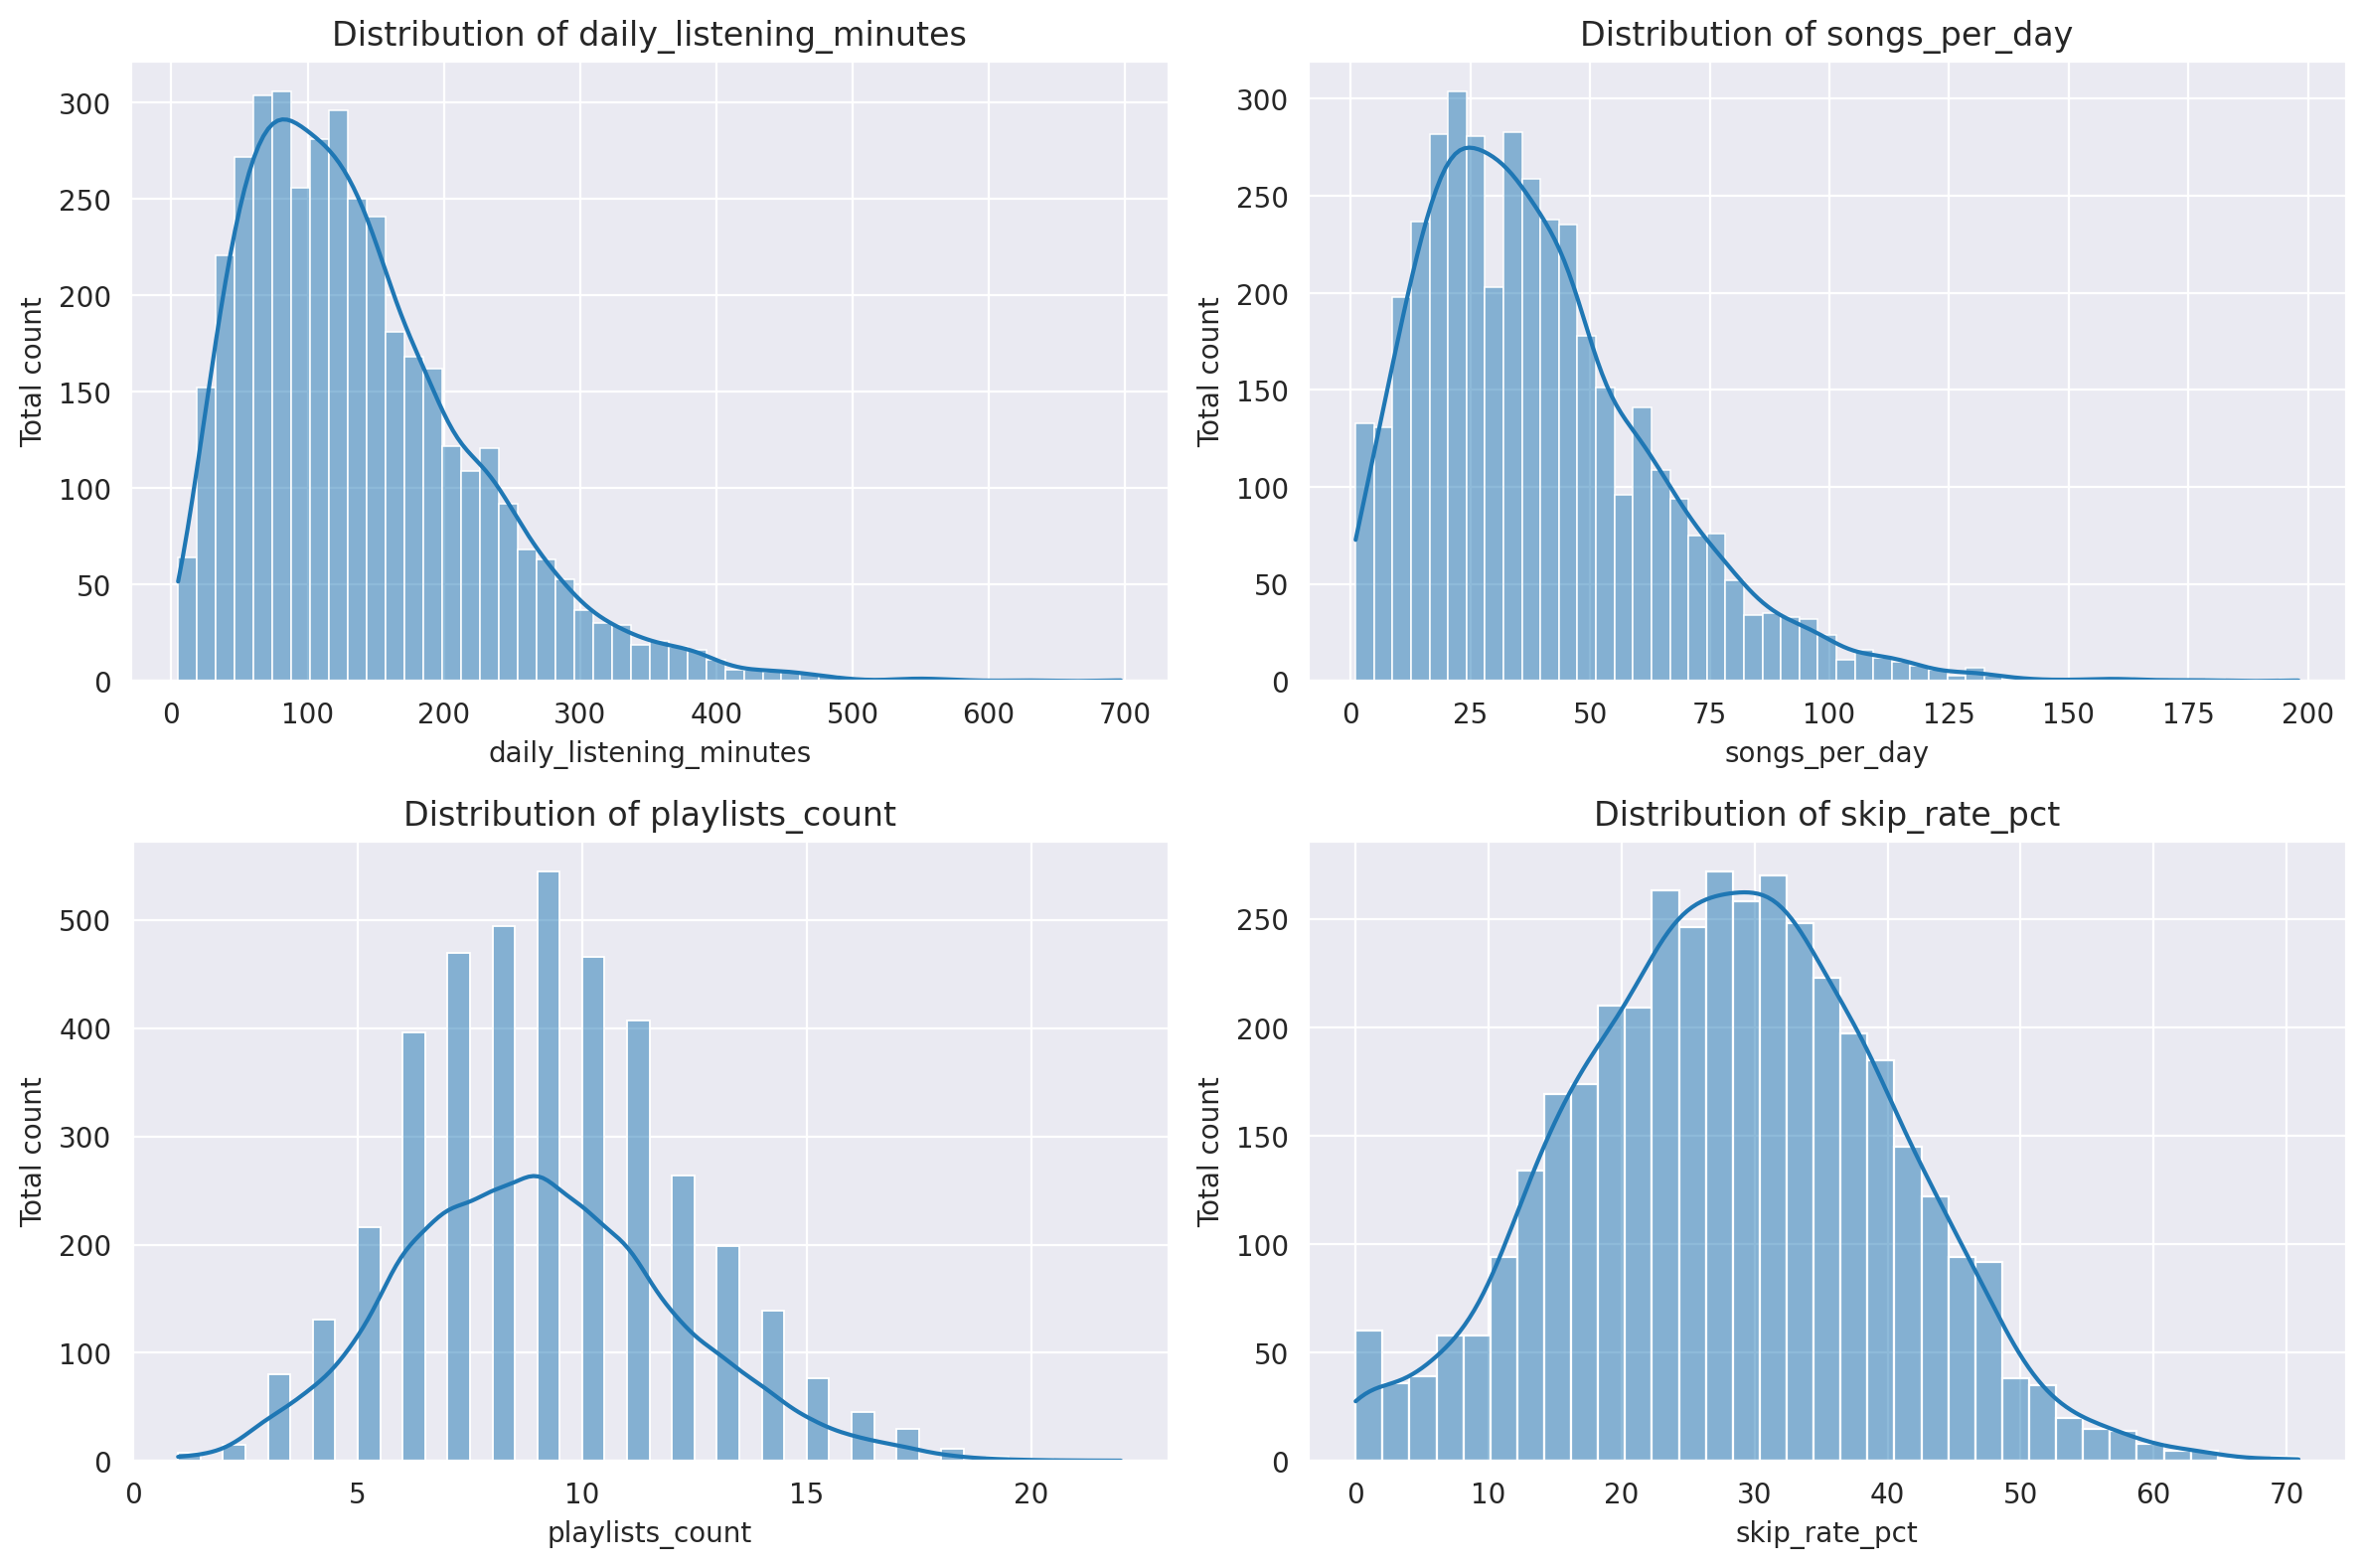

In [477]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(numeric_col):
    sns.histplot(data=df_train, x=col, kde=True, ax=ax.flat[i])
    ax.flat[i].set_title(f'Distribution of {col}')
    ax.flat[i].set_xlabel(col)
    ax.flat[i].set_ylabel('Total count')

fig.tight_layout()
plt.show()

- `daily_listening_minutes` is right-skewed, with most values between 50–200 minutes and a long tail toward higher values.
- `songs_per_day` is right-skewed, with a long tail toward higher values.
- `playlists_count` is approximately bell-shaped with a slight right skew.
- `skip_rate_pct` is approximately bell-shaped with no meaningful skew.

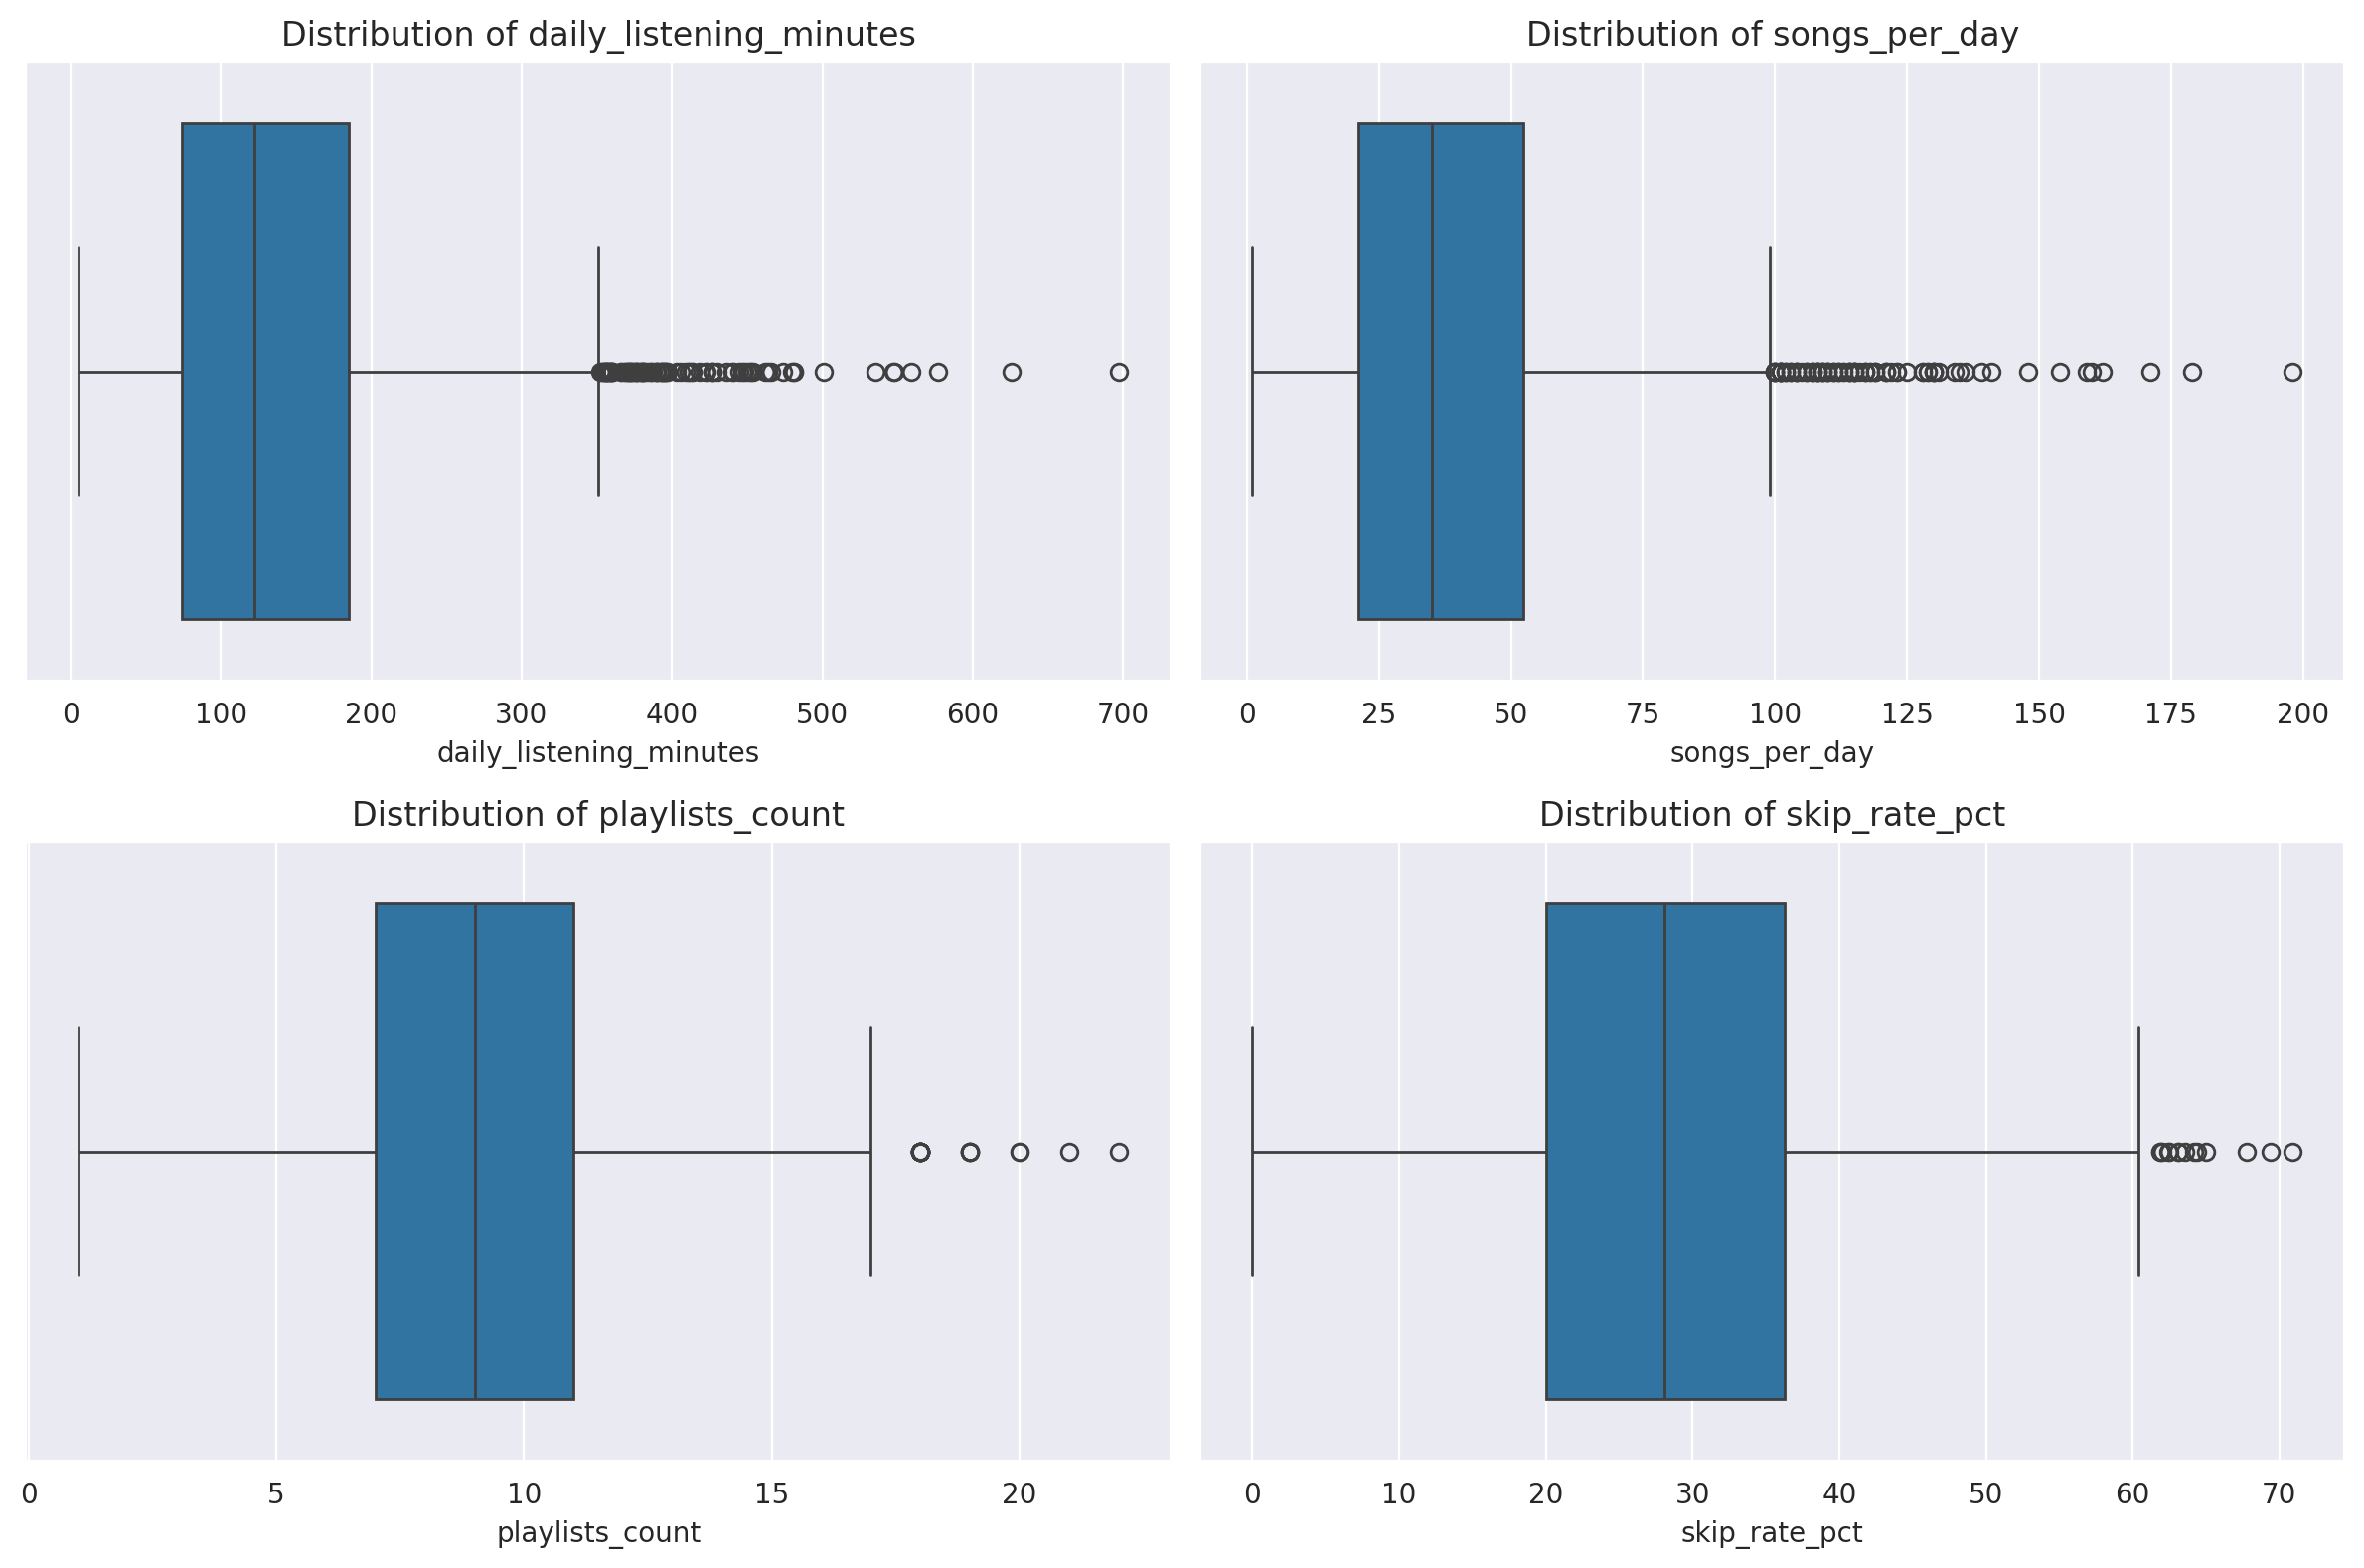

In [478]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(numeric_col):
    sns.boxplot(data=df_train, x=col, ax=ax.flat[i])
    ax.flat[i].set_title(f'Distribution of {col}')
    ax.flat[i].set_xlabel(col)

fig.tight_layout()
plt.show()

- `daily_listening_minutes` has many upper outliers and no lower outliers.
- `songs_per_day` has many upper outliers.
- `playlists_count` has a small number of outliers.
- `skip_rate_pct` has a small number of outliers.

**Interpretation:**

| Feature | Distribution | Suggested Preprocessing |
|---------|--------------|-------------------------|
| `daily_listening_minutes` | Right-skewed with many outliers | RobustScaler or log transform |
| `songs_per_day` | Right-skewed with many outliers | RobustScaler or log transform |
| `playlists_count` | Approximately bell-shaped | StandardScaler |
| `skip_rate_pct` | Approximately bell-shaped | StandardScaler |

Since K-Means computes distances using all numeric features simultaneously, each
feature's scale must be handled based on its own distribution rather than applying
one scaler uniformly. Skewed features (`daily_listening_minutes`, `songs_per_day`)
are scaled with `RobustScaler` to limit the influence of outliers, while the
near-symmetric features (`playlists_count`, `skip_rate_pct`) are scaled with
`StandardScaler`. Both strategies were still validated against clustering
performance (`Silhouette Score`) rather than assumed correct outright.

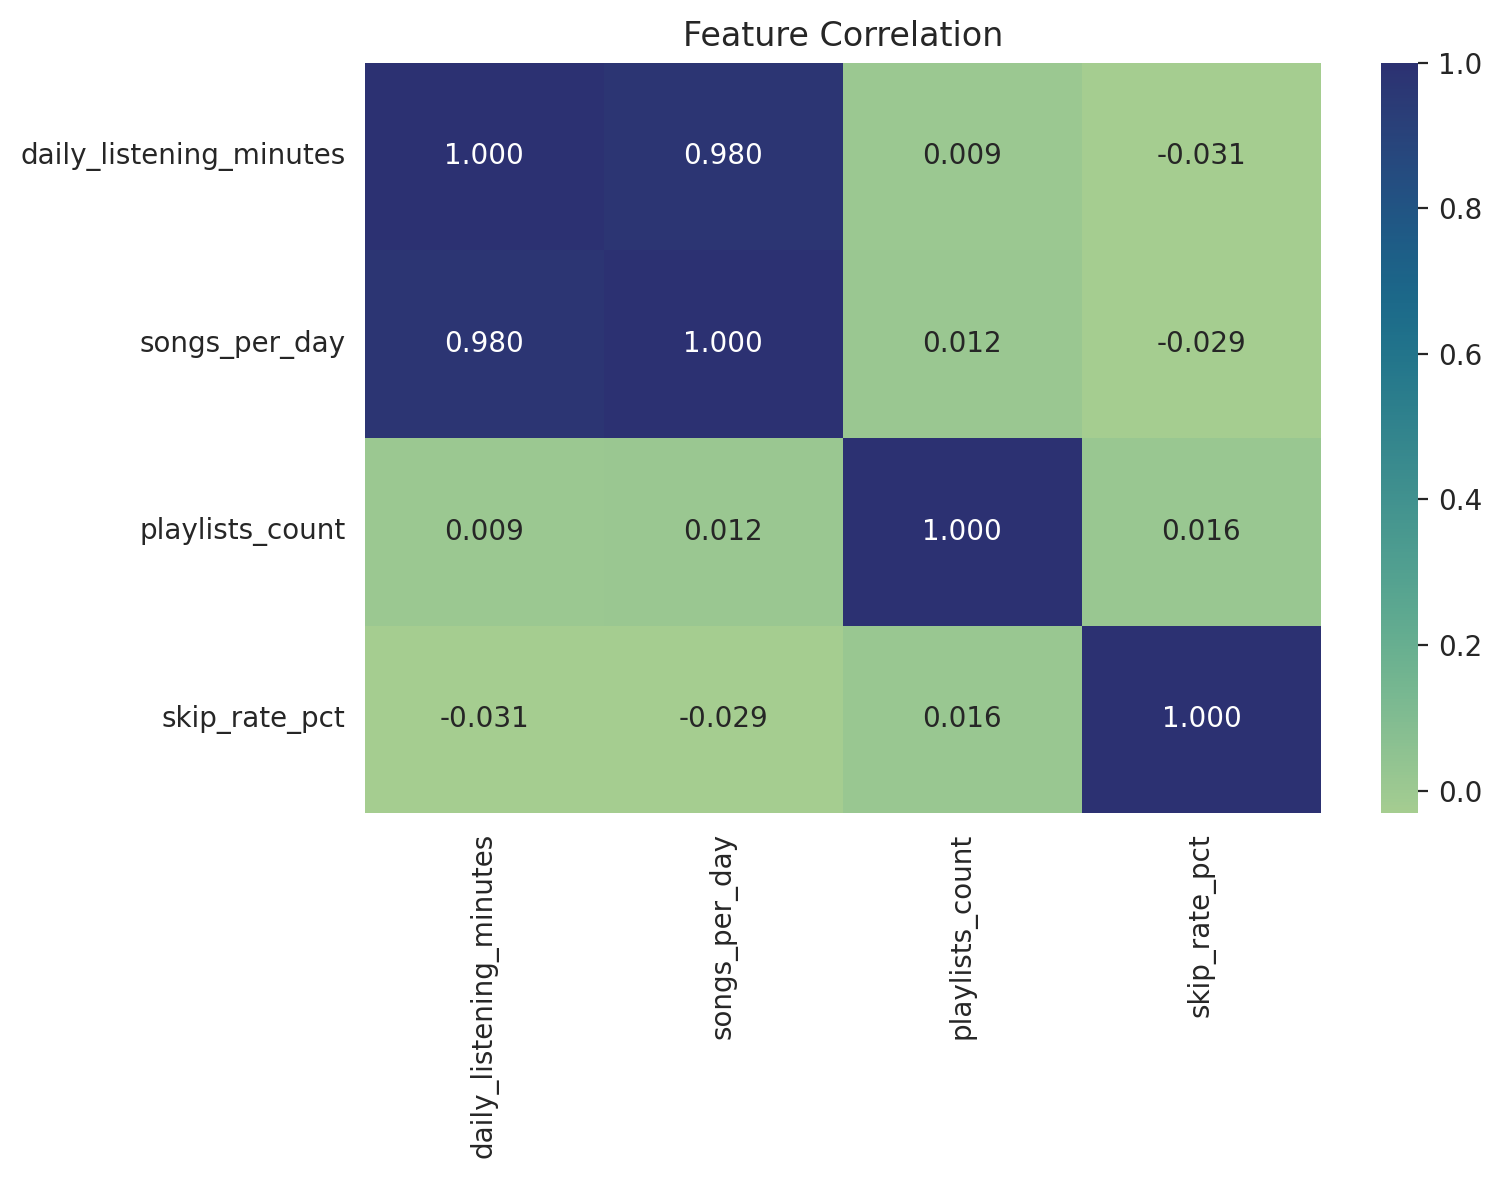

In [479]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_train[numeric_col].corr(), annot=True, cmap='crest', fmt='.3f')
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

**Interpretation:**

`daily_listening_minutes` and `songs_per_day` show a very strong correlation
(0.98), indicating the two features are almost entirely redundant. This supports
combining them into a single engineered feature rather than keeping both, to
avoid double-counting the same signal in clustering. All other feature pairs show
little to no correlation.

In [480]:
bool_col = list(df_train.select_dtypes(include=['bool']).columns)
print(bool_col)

['discover_weekly_user', 'uses_offline_mode', 'podcasts_too']


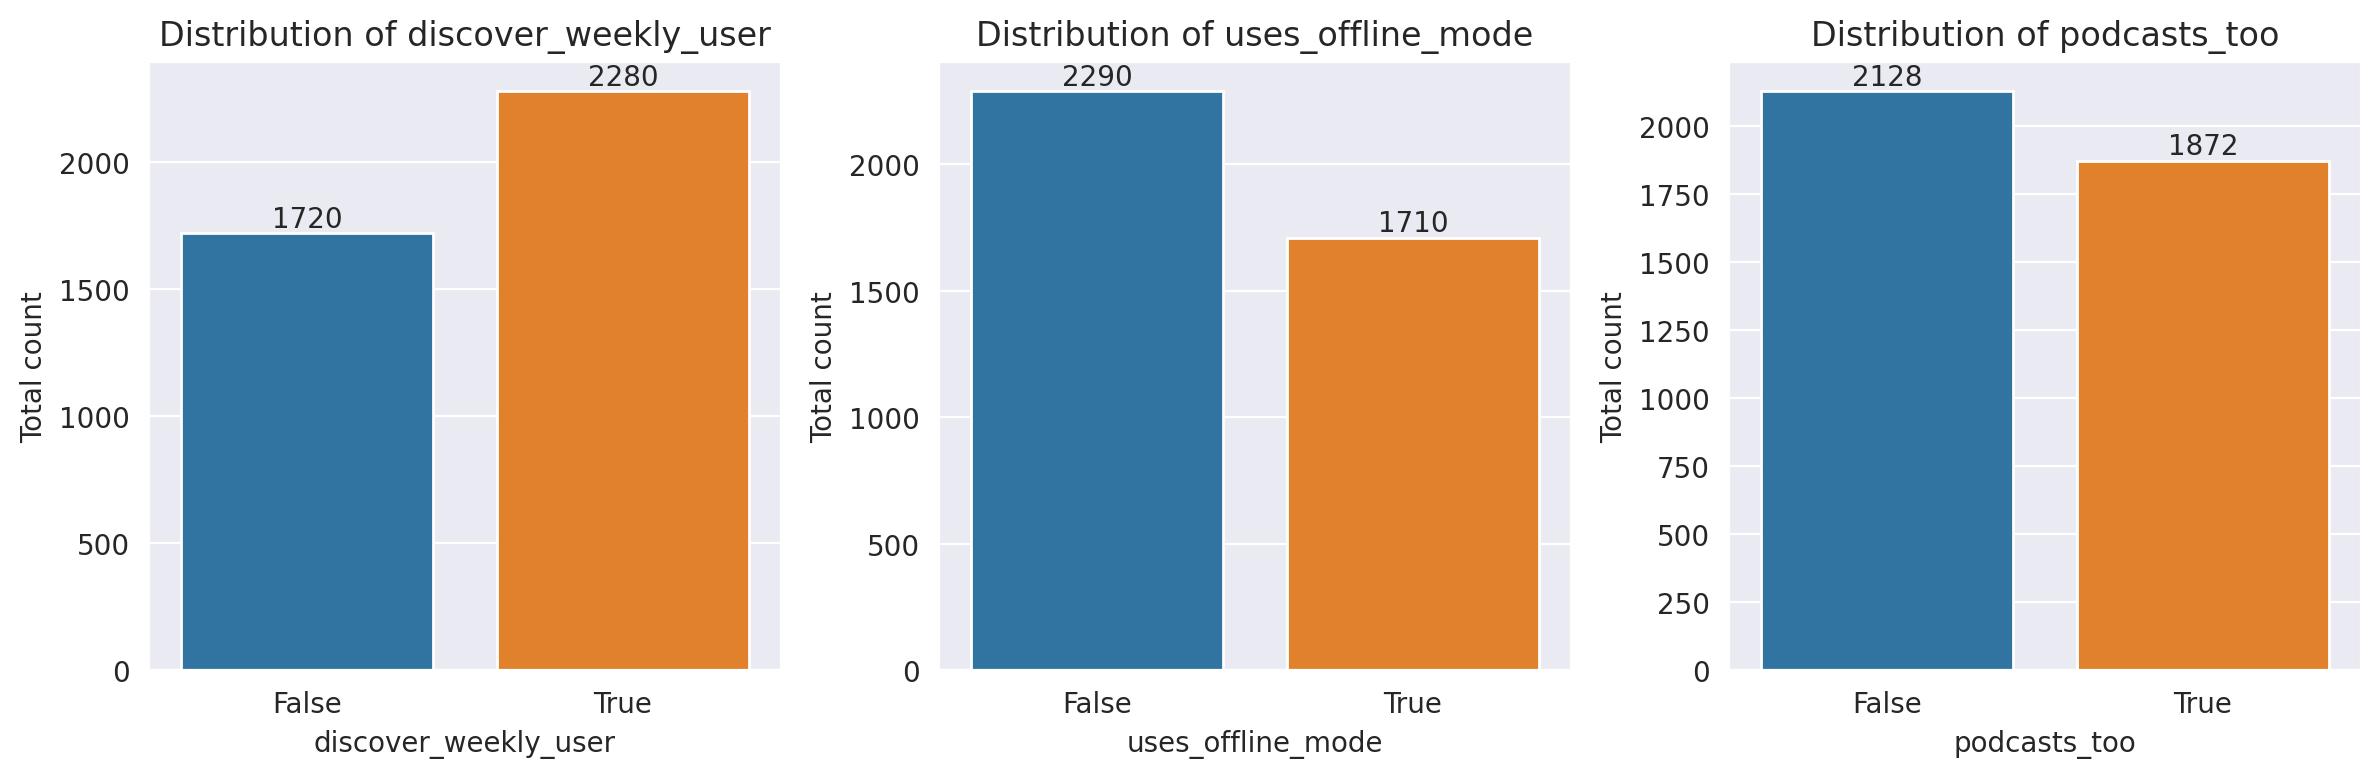

In [481]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(bool_col):
    sns.countplot(data=df_train, x=col, ax=ax[i], hue=col, legend=False)
    ax[i].set_title(f'Distribution of {col}')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Total count')

    for container in ax[i].containers:
        ax[i].bar_label(container)

fig.tight_layout()
plt.show()

**Interpretation:**

`discover_weekly_user`, `uses_offline_mode`, and `podcasts_too` all show reasonably
balanced distributions between `True` and `False` (roughly 43–57% split in each
case). None of the three is near-constant, so all are retained as potentially
useful signal for K-Means clustering.

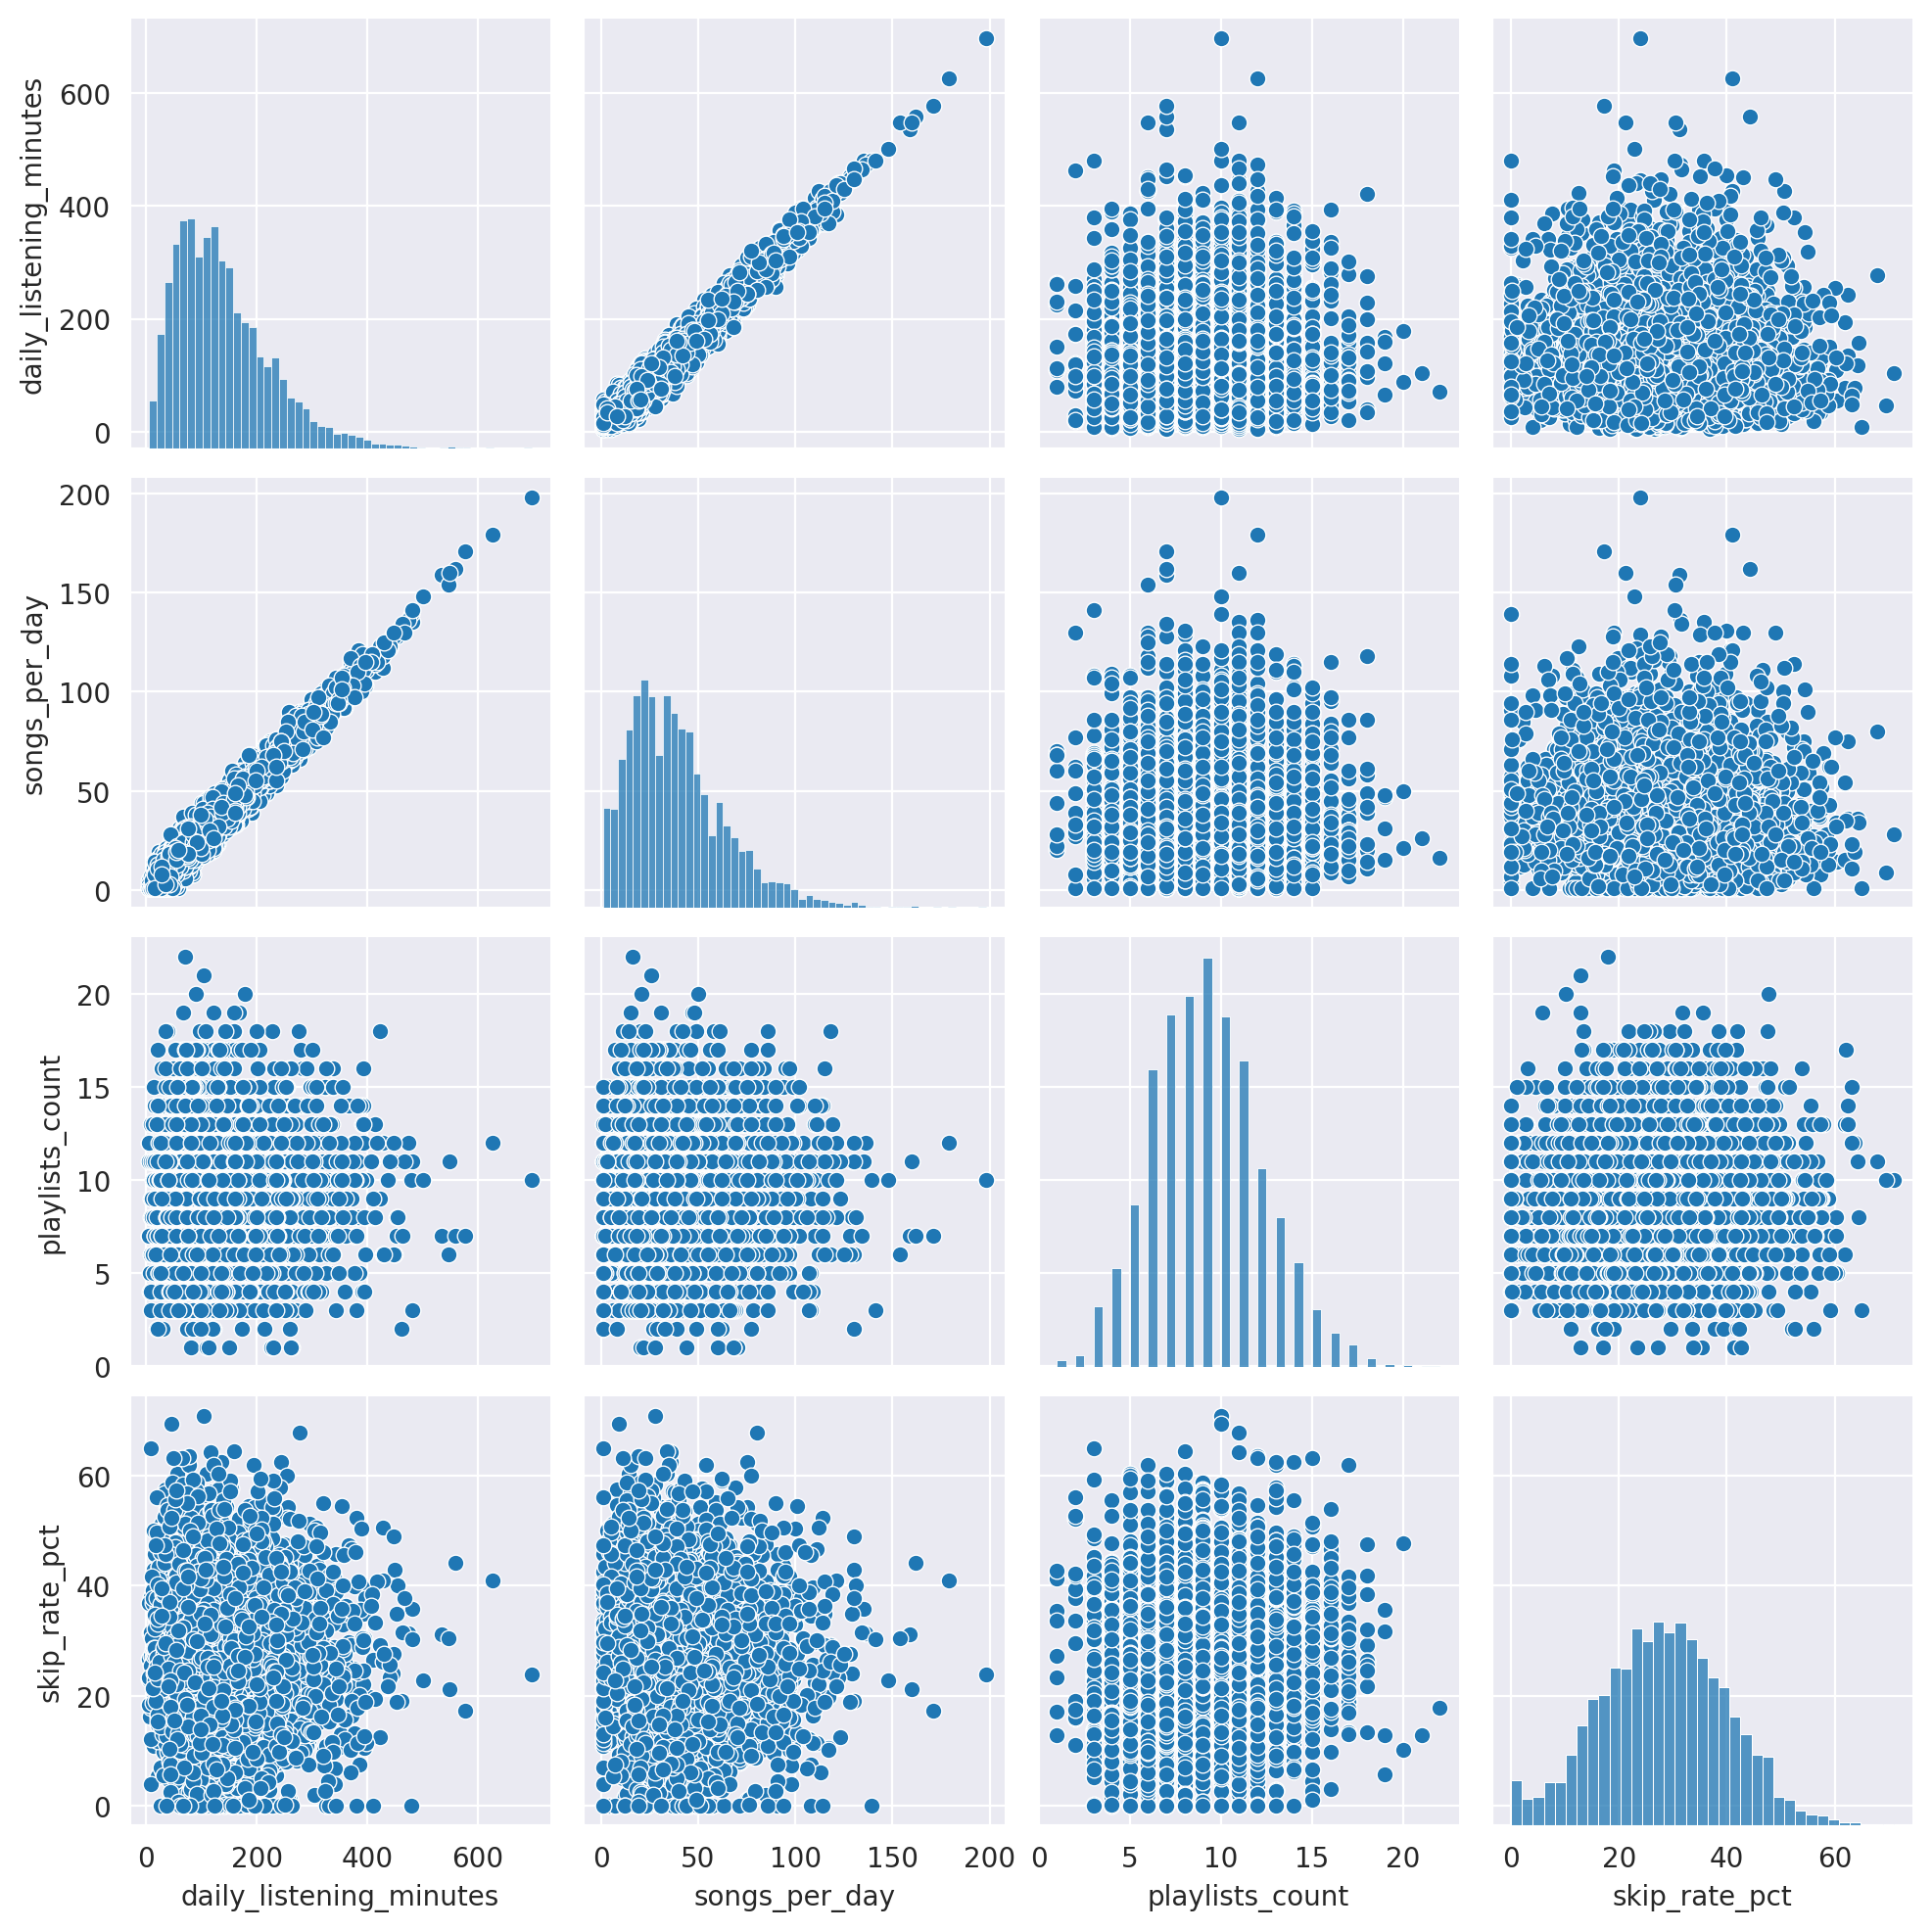

In [482]:
sns.pairplot(df_train[numeric_col])
plt.show()

## Profiling Features

In [483]:
profile_obj_col = list(df_profile.select_dtypes(include=['object']).columns)
print(profile_obj_col)

['country', 'platform', 'subscription', 'top_genre', 'top_mood']


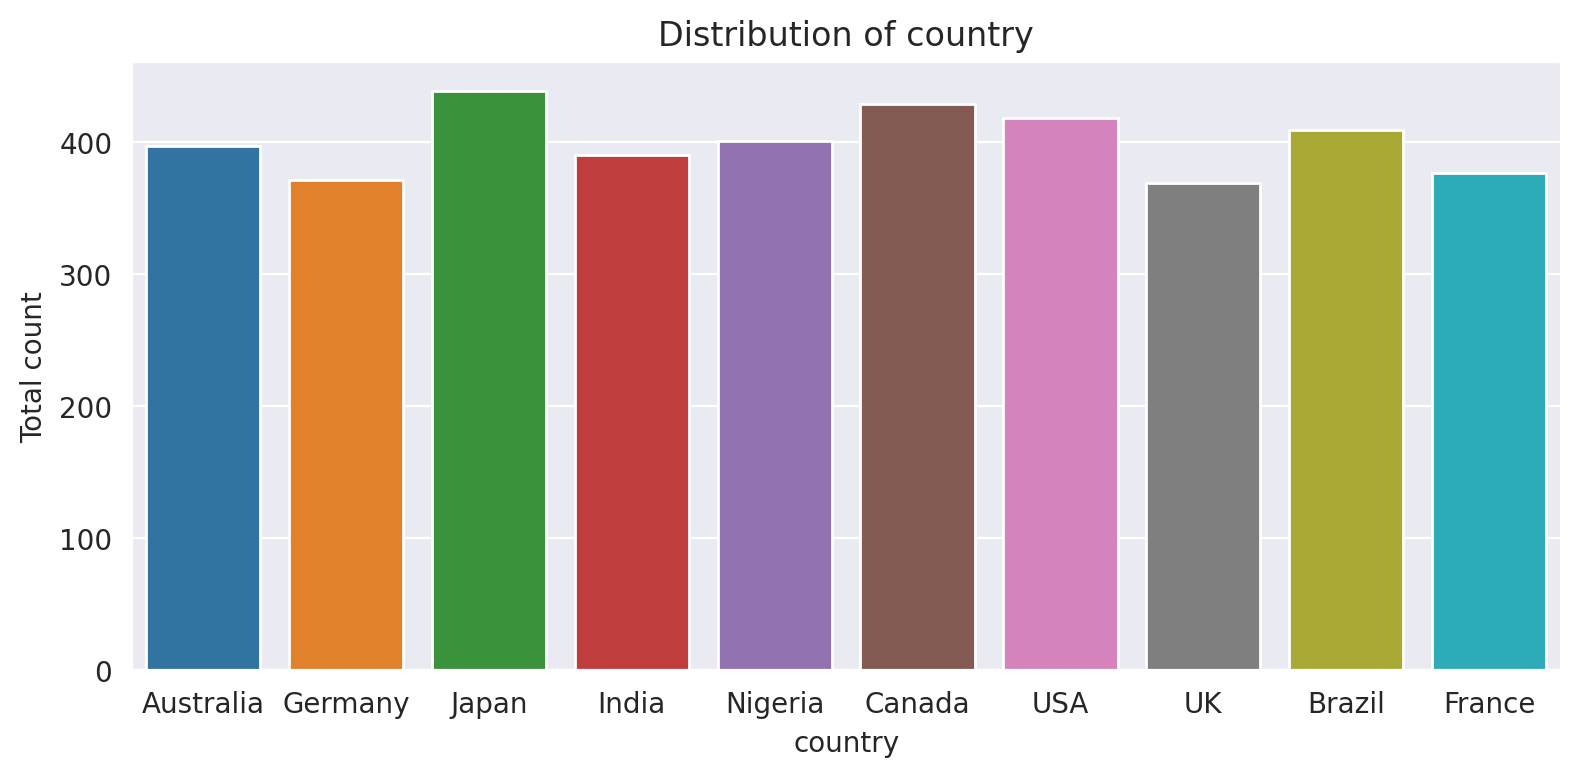

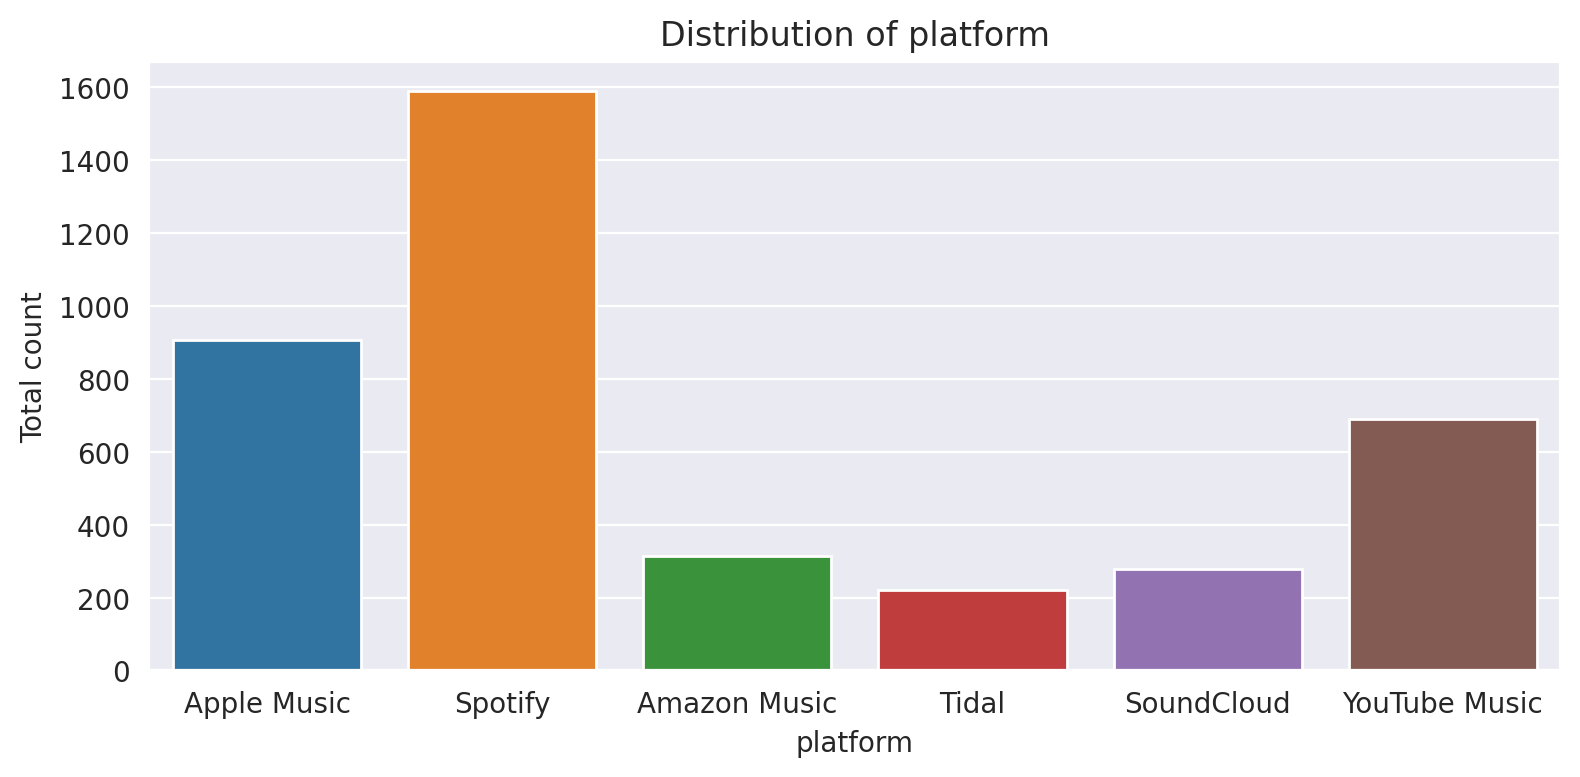

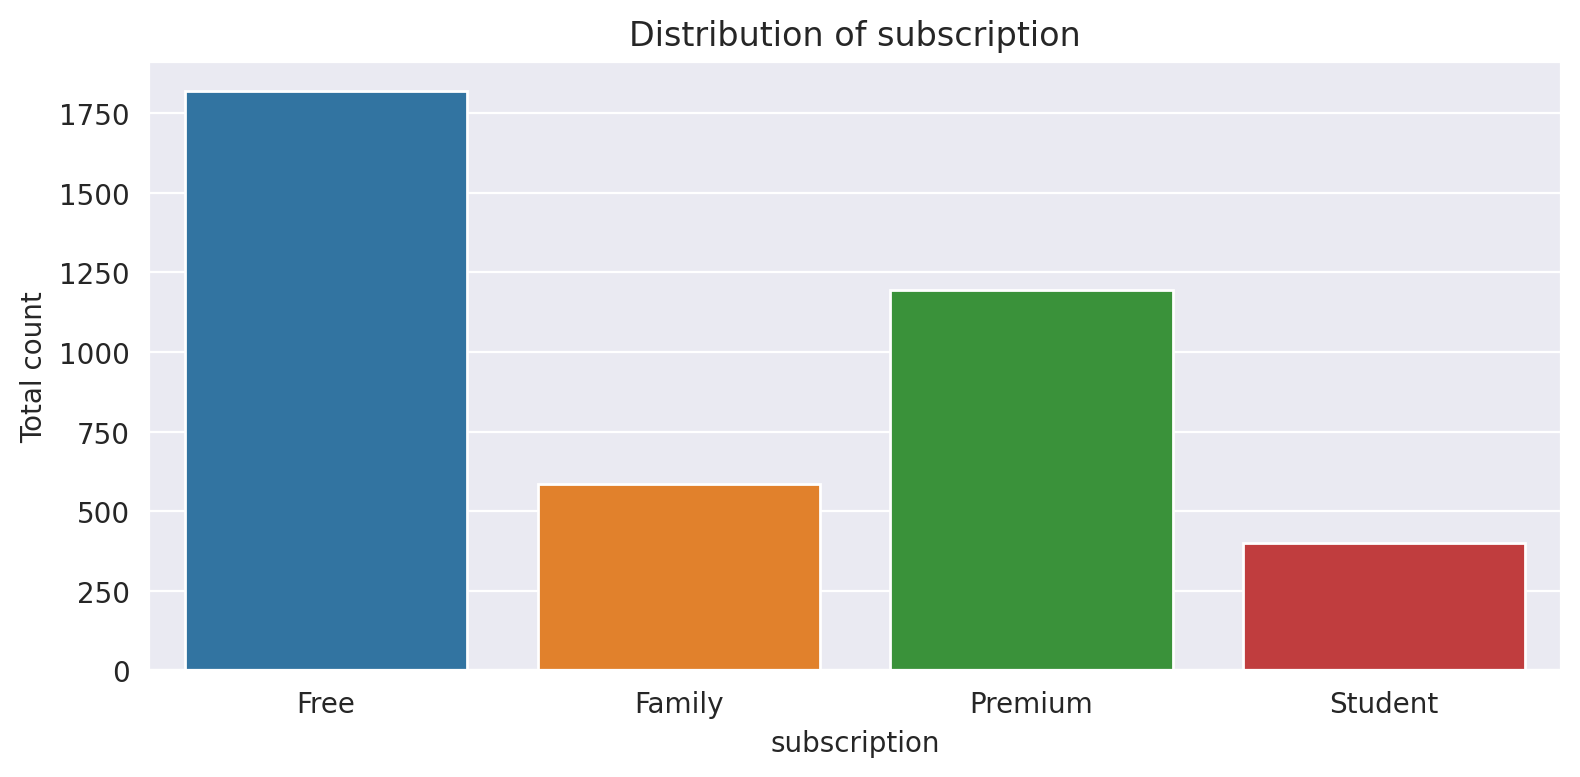

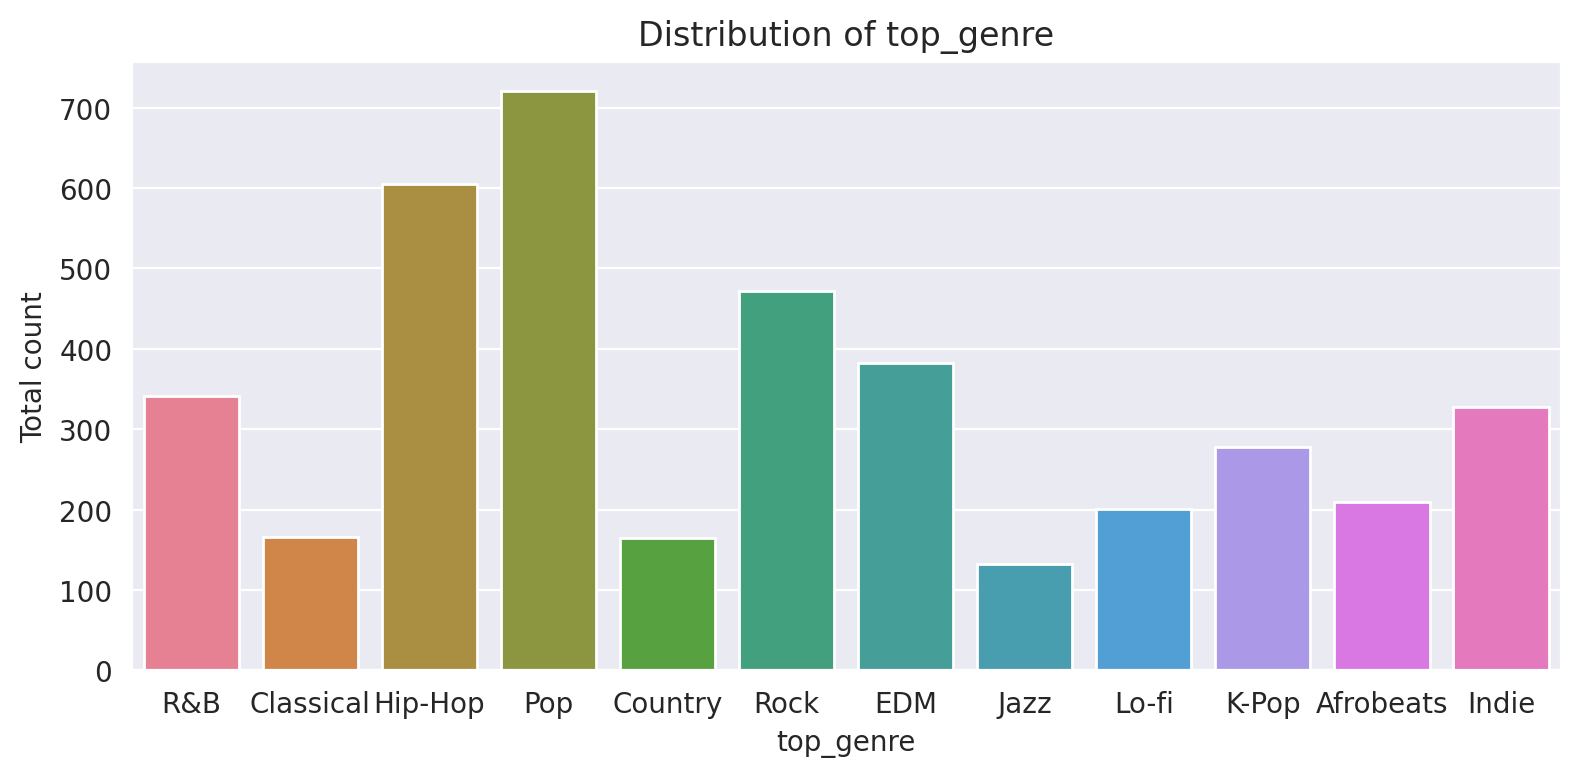

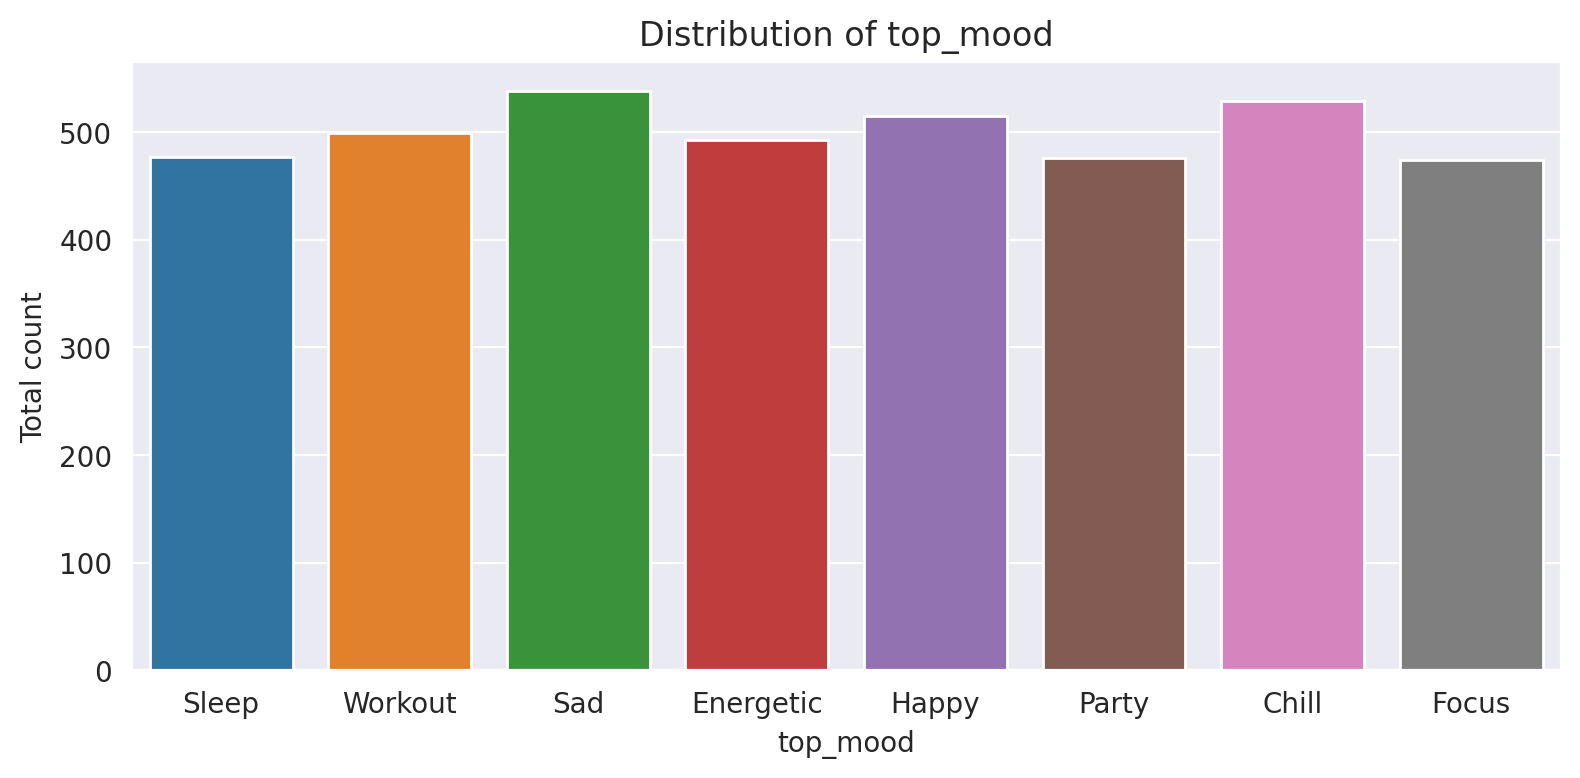

In [484]:
for col in profile_obj_col:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_profile, x=col, hue=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Total count')
    plt.tight_layout()
    plt.show()

**Interpretation:**

- `country` and `top_mood` are nearly evenly distributed across categories,
  giving a stronger basis for cluster profiling — an overrepresented category
  within a cluster is more likely to reflect a real pattern rather than the
  category's general prevalence.
- `platform`, `subscription`, and `top_genre` show moderate imbalance but
  remain usable for profiling, provided each cluster's distribution is compared
  against the overall dataset distribution rather than read in isolation.
- None of the profiling features are heavily dominated by a single category,
  so all five can be used to characterize clusters. A feature dominated by one
  category would offer weaker evidence for distinguishing clusters, since that
  category would already be common throughout the dataset.

## Model Training vs Profiling Features

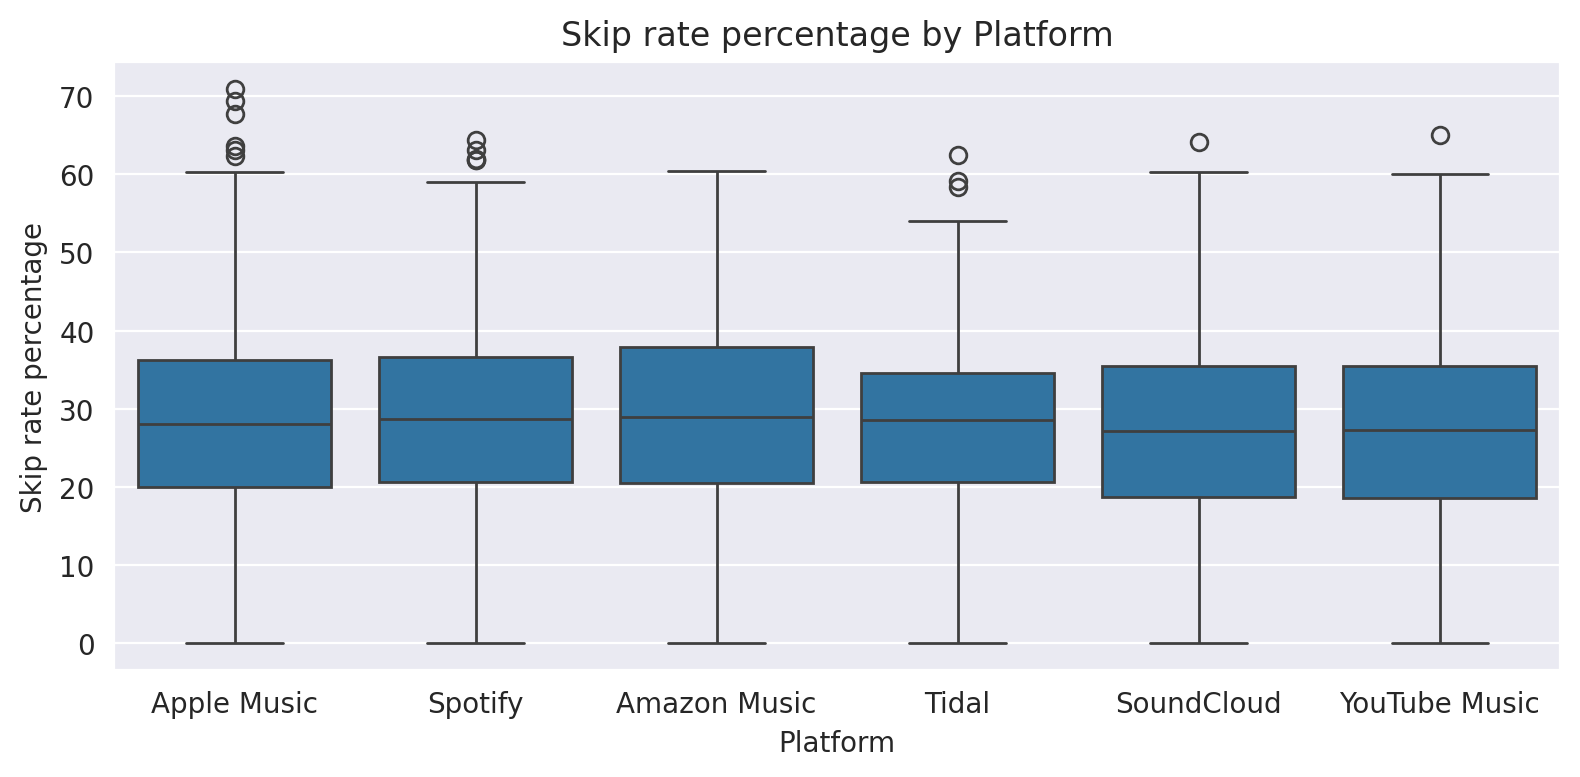

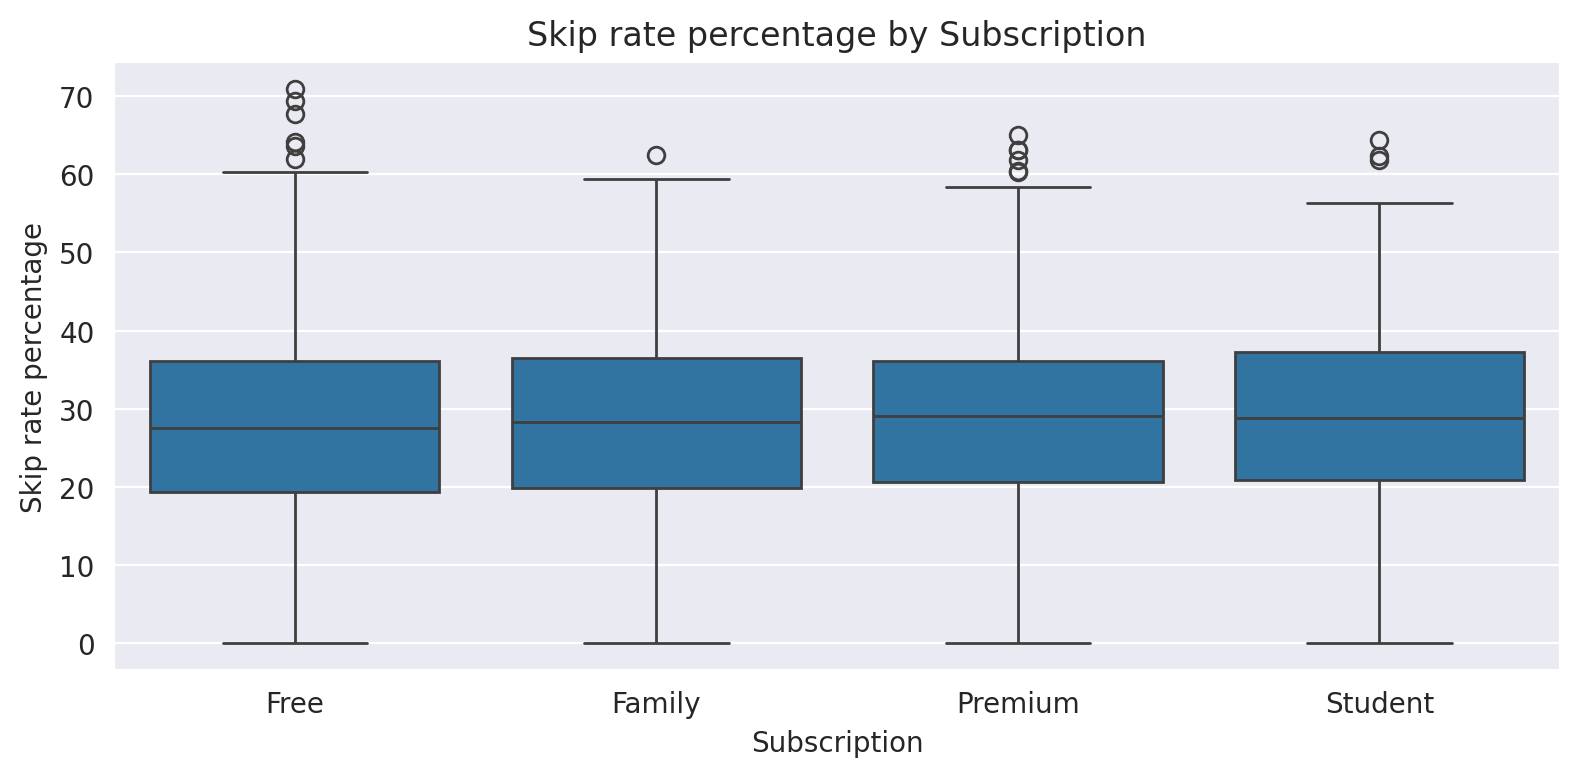

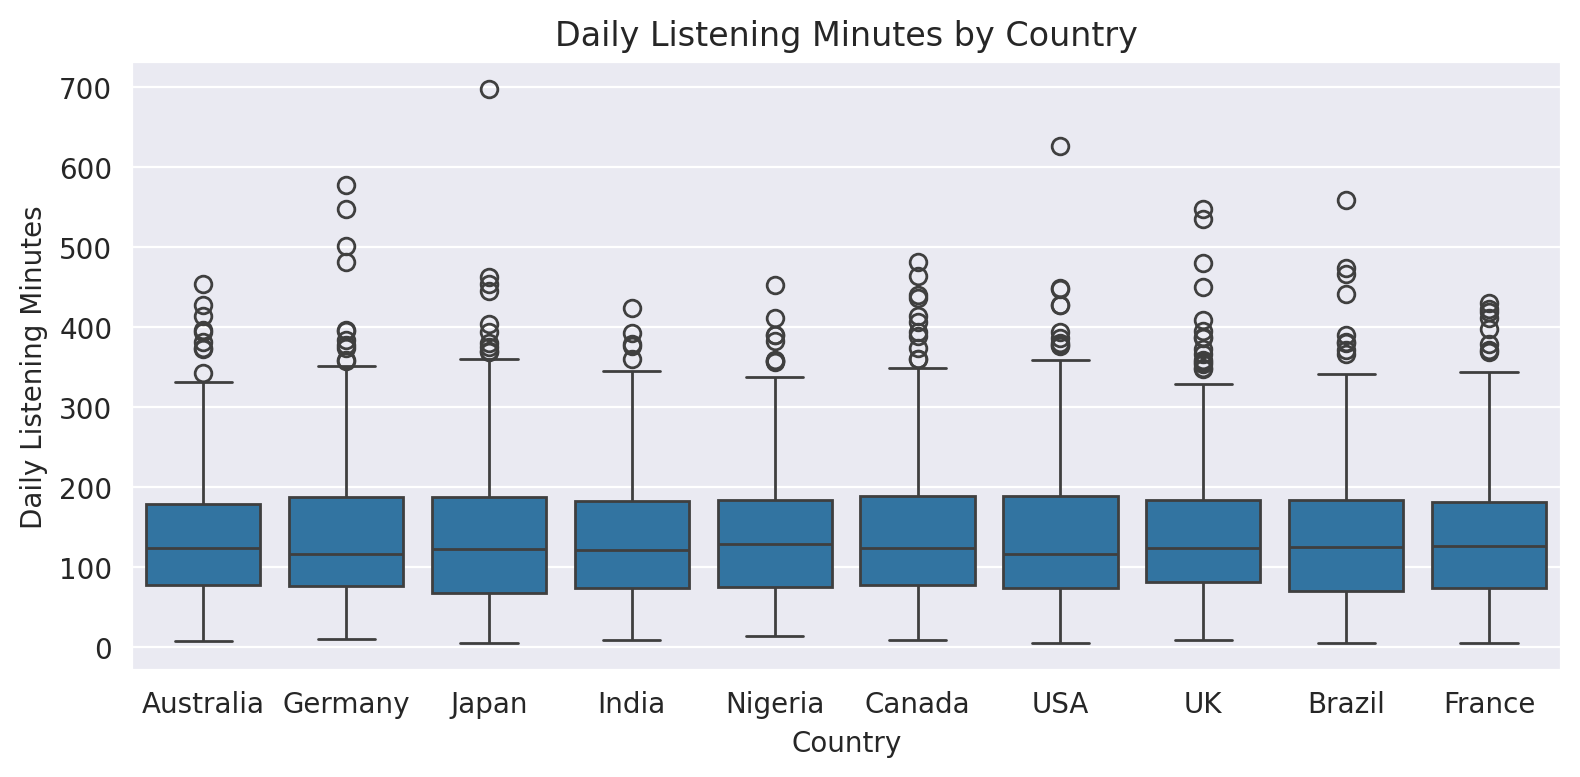

In [485]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='platform', y='skip_rate_pct')
plt.title('Skip rate percentage by Platform')
plt.xlabel('Platform')
plt.ylabel('Skip rate percentage')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='subscription', y='skip_rate_pct')
plt.title('Skip rate percentage by Subscription')
plt.xlabel('Subscription')
plt.ylabel('Skip rate percentage')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='country', y='daily_listening_minutes')
plt.title('Daily Listening Minutes by Country')
plt.xlabel('Country')
plt.ylabel('Daily Listening Minutes')
plt.tight_layout()
plt.show()

**Interpretation:**

`skip_rate_pct` and `daily_listening_minutes` show similar averages across
`platform`, `subscription`, and `country`. This suggests behavioral features 
are not strongly associated with these profiling features, reducing the 
likelihood that the resulting K-Means clusters simply reflect differences in 
users' platform, subscription type, or country.

# Feature Engineering

In [486]:
# Ensure no divide-by-zero when creating average_song_length
assert (df_train['songs_per_day'] > 0).all()

df_train['average_song_length'] = df_train['daily_listening_minutes'] / df_train['songs_per_day']
df_train.drop(columns=['songs_per_day'], inplace=True)

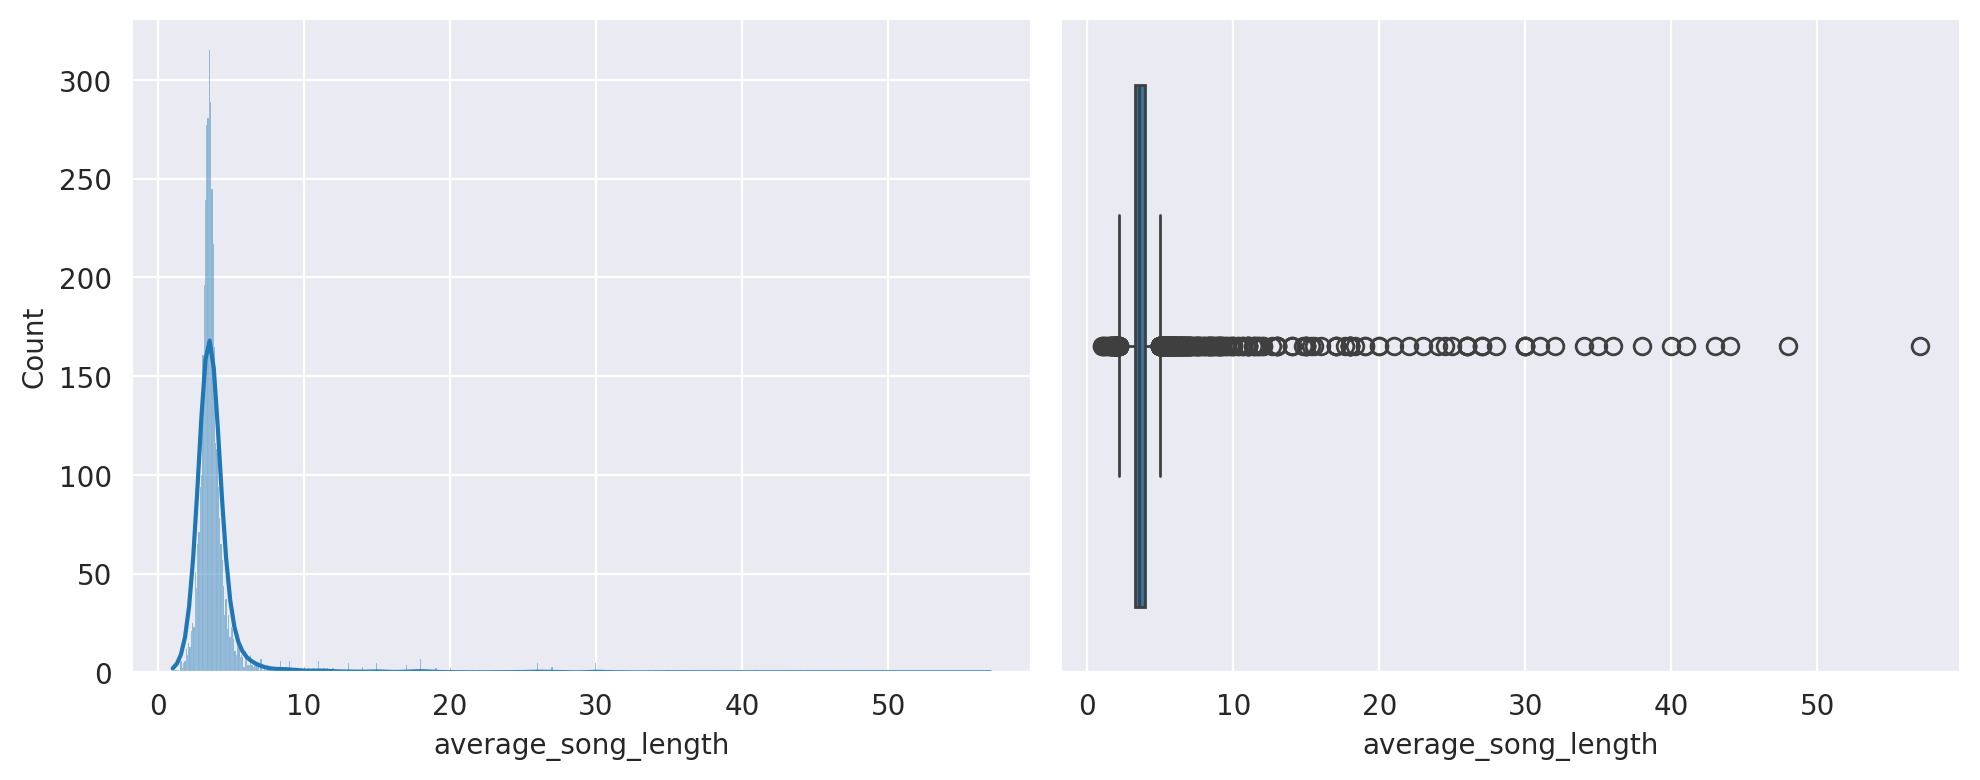

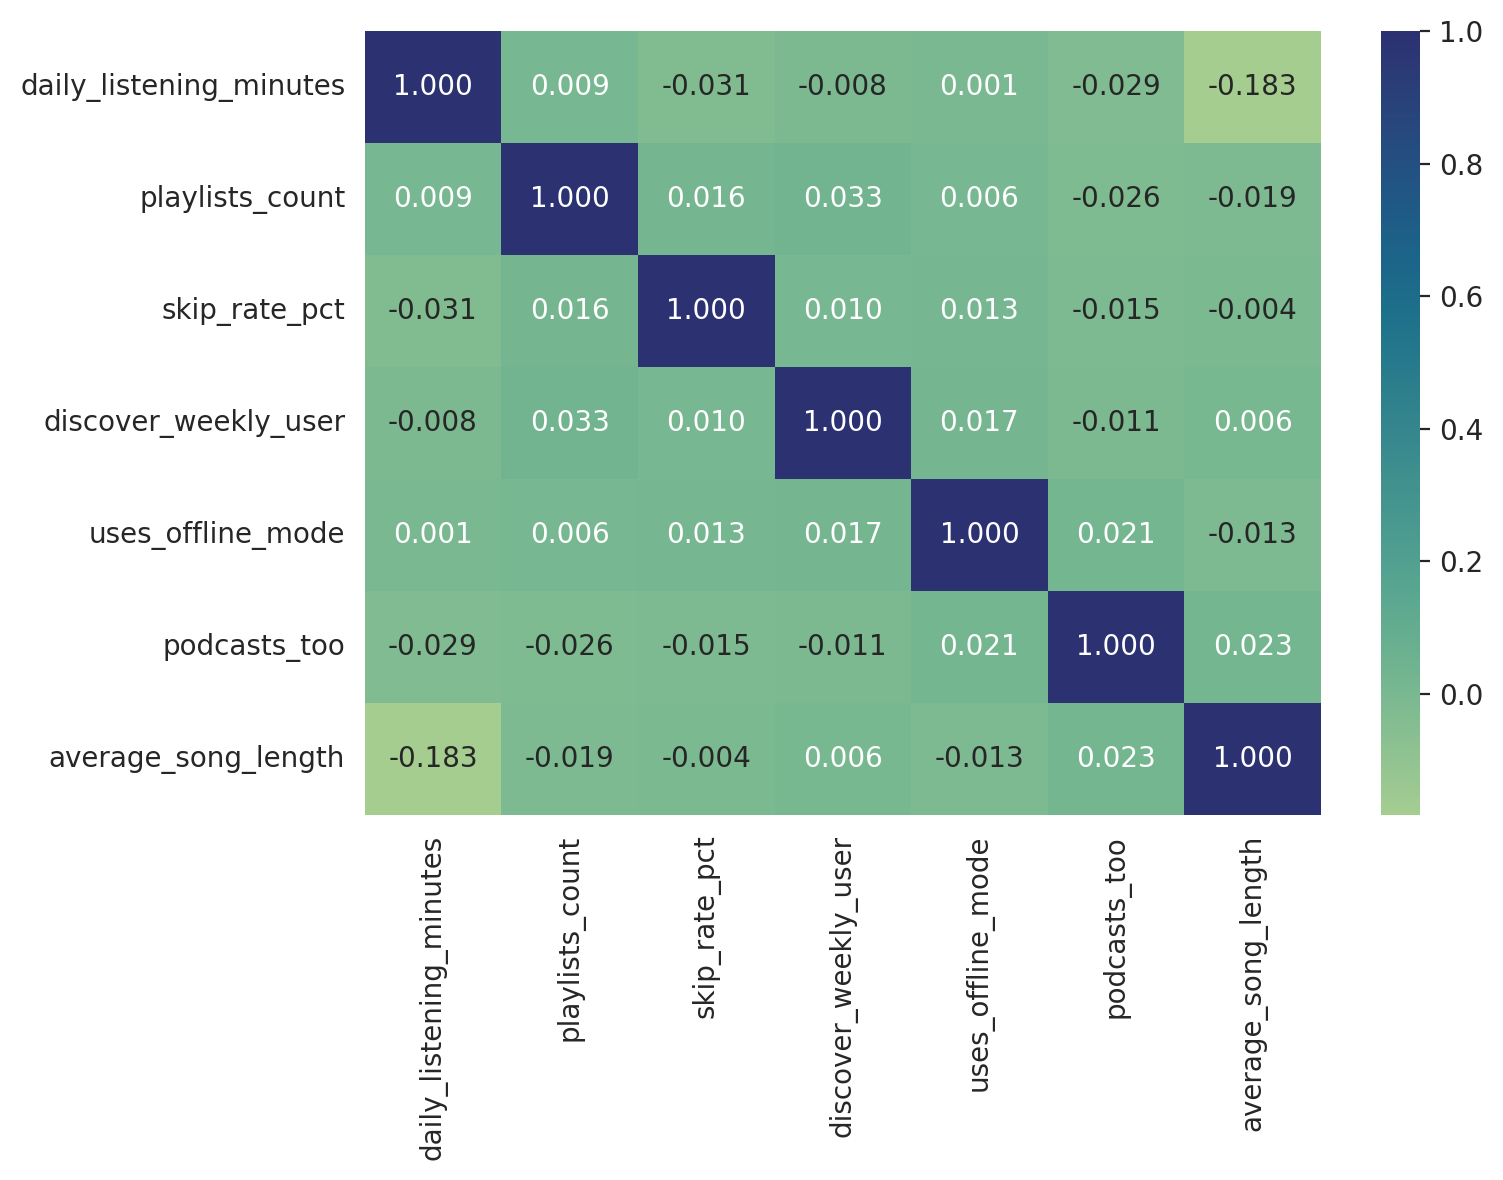

In [487]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(data=df_train, x='average_song_length', kde=True, ax=ax[0])
sns.boxplot(data=df_train, x='average_song_length', ax=ax[1])
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='crest', fmt='.3f')
plt.tight_layout()
plt.show()

**Interpretation:**

`daily_listening_minutes` and `songs_per_day` were highly correlated (0.98),
meaning both were effectively measuring the same underlying signal ("how much
someone listens") twice. To resolve this, they were combined into a single
derived feature, `average_song_length`, capturing listening style rather than
raw volume, and `songs_per_day` was dropped to avoid redundancy.

The distribution and boxplot show `average_song_length` is heavily right-skewed,
with a long tail of outliers extending toward 57 minutes per song.

The correlation heatmap confirms the fix worked: `average_song_length` correlates
weakly with `daily_listening_minutes` (-0.18) and negligibly with every other
feature (all under 0.03), meaning the redundancy is resolved.

In [488]:
df_train['average_song_length_log'] = np.log1p(df_train['average_song_length'])
df_train.drop(columns=['average_song_length'], inplace=True)

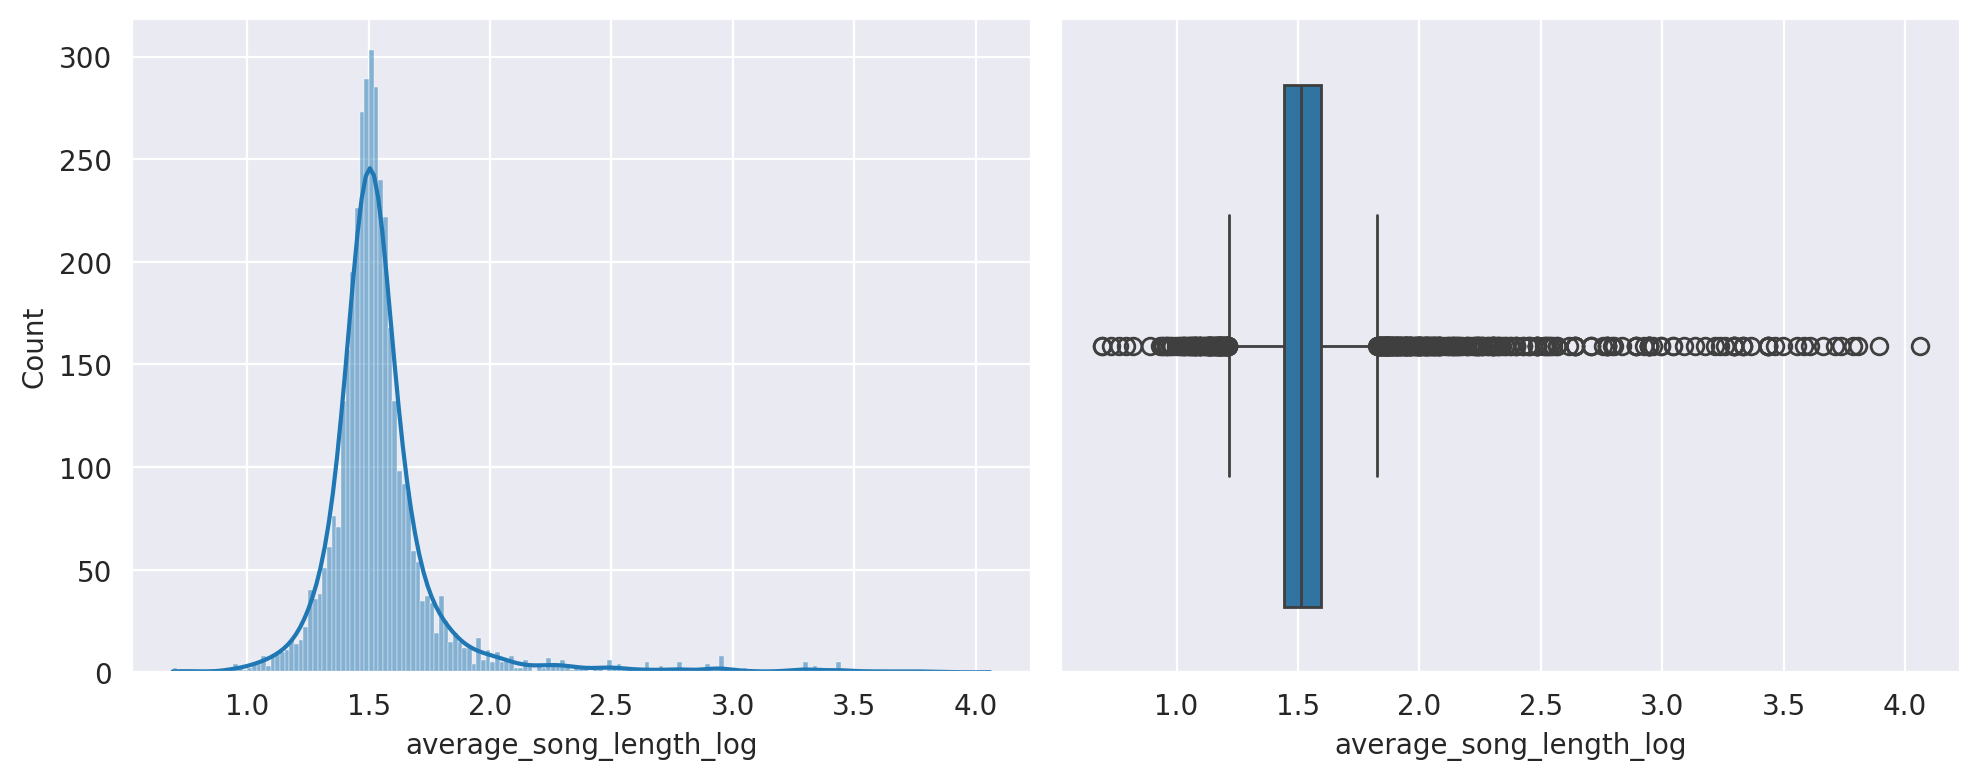

In [489]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_train['average_song_length_log'], kde=True, ax=ax[0])
sns.boxplot(x=df_train['average_song_length_log'], ax=ax[1])
fig.tight_layout()
plt.show()

**Interpretation:**

`average_song_length` remained heavily right-skewed after engineering, with a 
long tail of extreme outliers. A `log1p` transform was applied to compress
this tail (`log1p` instead of `log` to safely handle any value ≥ 0, including 0).

The transform substantially reduced skew and compressed the range from roughly 
1–57 down to 0.7–4.1. The distribution is closer to bell-shaped but still shows 
some residual skew — the boxplot's remaining outlier points reflect this mild, 
leftover skew rather than the severe distortion seen before the transform.

The raw `average_song_length` was dropped in favor of the log-transformed version
to avoid carrying two versions of the same signal into modeling.

In [490]:
cap_value = df_train['average_song_length_log'].quantile(0.99)
df_train['average_song_length_log'] = df_train['average_song_length_log'].clip(upper=cap_value)

**Why Cap `average_song_length_log` Before Re-Running Model Selection**

The initial model selection produced an unusually high silhouette score at
`k = 2` (~0.65), which was traced to a degenerate split (138 vs. 3,862 listeners)
driven by extreme outliers rather than meaningful user groups. Further investigation
showed these outliers came from unstable `average_song_length` values caused by
very low `songs_per_day`, which made the ratio disproportionately large for a
small number of listeners.

To reduce this distortion while preserving genuine listening behavior,
`average_song_length_log` was capped at the 99th percentile, affecting only the
most extreme values. Model selection was then repeated for `k = 3` through `k = 8`
(the range still under consideration, since `k = 2` was already excluded as
degenerate). The post-cap results showed a clearer, more interpretable pattern —
scores rose from `k = 3` to a peak at `k = 6` (~0.167) before declining, compared
to the flat, noisy scores across this range before capping.

# Preprocessing

In [491]:
df_train[bool_col] = df_train[bool_col].astype(int)

In [492]:
# RobustScaler (skewed, has outliers): daily_listening_minutes, average_song_length_log
# StandardScaler (approximately normal): playlists_count, skip_rate_pct
robust_col = ['daily_listening_minutes', 'average_song_length_log']
standard_col = ['playlists_count', 'skip_rate_pct']

preprocessor = ColumnTransformer([
    ('robust', RobustScaler(), robust_col),
    ('standard', StandardScaler(), standard_col),
    ('bool', 'passthrough', bool_col),
])

X_features = preprocessor.fit_transform(df_train)

# Model Selection

In [493]:
silhouette_scores = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_features)
    silhouette_scores[k] = silhouette_score(X_features, labels)

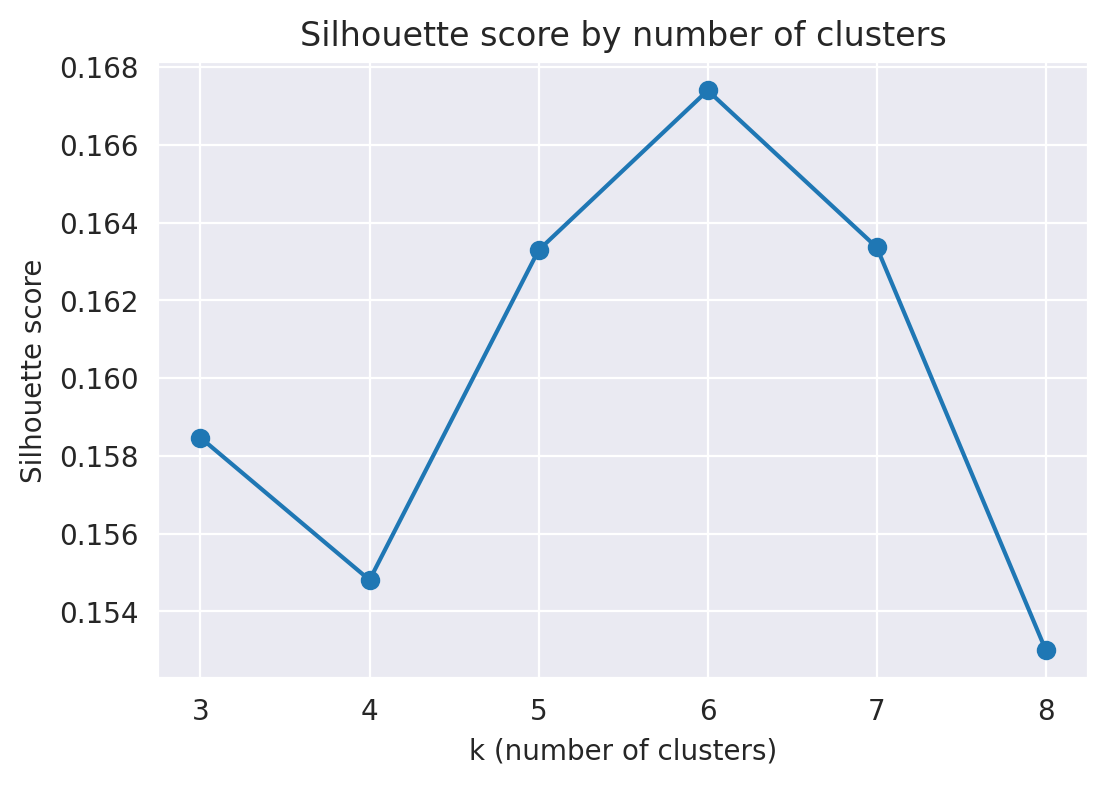

In [516]:
plt.figure(figsize=(6, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score by number of clusters')
plt.show()

**Interpretation:**

The final model achieved a silhouette score of approximately `0.15–0.17` across
`k = 3–8`, indicating weak-to-moderate cluster separation. This reflects the
nature of the data rather than a modeling issue, as listening behavior varies
continuously instead of forming naturally distinct groups.

Several additional engineered features (`songs_per_playlist`, `skip_intensity`,
and `loyalty_score`) were considered but not implemented, as each was found
likely to either reintroduce the same ratio-instability problem already resolved
in `average_song_length_log`, or duplicate information already captured by
existing features.

Despite the modest silhouette score, the clusters remain interpretable,
exhibiting meaningful differences in listening behavior such as daily listening
time and skip rate. Therefore, the six clusters should be interpreted as
`general behavioral tendencies` rather than strictly separated user categories.

# Fit Final Model

In [495]:
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_train['cluster'] = kmeans_final.fit_predict(X_features)

In [517]:
df_train['cluster'].value_counts().sort_index()

cluster
0     375
1     892
2     107
3    1068
4    1087
5     471
Name: count, dtype: int64

**Interpretation:**

Cluster sizes range from 107 to 1,087 listeners. No cluster is suspiciously tiny or dominant, unlike the degenerate 138-vs-3,862 split observed at `k = 2` — confirming this is not the same outlier-driven pattern.

In [518]:
smallest_cluster = df_train['cluster'].value_counts().idxmin()
df_train.loc[df_train['cluster'] == smallest_cluster].drop(columns='cluster').describe(include='all')

,daily_listening_minutes,playlists_count,skip_rate_pct,discover_weekly_user,uses_offline_mode,podcasts_too,average_song_length_log
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,33.140187,8.775701,27.752336,0.607477,0.401869,0.579439,2.707154
std,17.319663,2.988369,11.463382,0.490610,0.492583,0.495972,0.247132
min,9.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.277267
25%,18.000000,6.000000,21.100000,0.000000,0.000000,0.000000,2.484907
50%,31.000000,9.000000,28.200000,1.000000,0.000000,1.000000,2.772589
75%,44.000000,11.000000,36.550000,1.000000,1.000000,1.000000,2.944439
max,85.000000,15.000000,56.000000,1.000000,1.000000,1.000000,2.944439


**Interpretation:**

Examines the smallest cluster's internal feature ranges (min, max, spread) to
confirm it reflects a genuine, distinct listener group rather than a handful of
outliers — e.g. tight, bounded ranges support a real pattern, while wide spread
or extreme values relative to the mean would suggest noise.

# Bias/Validity Check

In [520]:
df_train.index.equals(df_profile.index)
df_profile['cluster'] = df_train['cluster']
df_profile['cluster'].isnull().sum()

np.int64(0)

In [523]:
for col in profile_col:
    print(f'--- {col} by cluster ---')
    if df_profile[col].dtype in ['int', 'float']:
        print(df_profile.groupby('cluster')[col].mean().round(1))
    else:
        print(df_profile.groupby('cluster')[col].agg(lambda c: c.value_counts(normalize=True).idxmax()))
    print()

--- age by cluster ---
cluster
0    28.1
1    27.9
2    28.0
3    27.8
4    27.9
5    27.6
Name: age, dtype: float64

--- country by cluster ---
cluster
0       Canada
1      Nigeria
2       France
3    Australia
4        Japan
5          USA
Name: country, dtype: object

--- platform by cluster ---
cluster
0    Spotify
1    Spotify
2    Spotify
3    Spotify
4    Spotify
5    Spotify
Name: platform, dtype: object

--- subscription by cluster ---
cluster
0    Free
1    Free
2    Free
3    Free
4    Free
5    Free
Name: subscription, dtype: object

--- top_genre by cluster ---
cluster
0        Pop
1        Pop
2    Hip-Hop
3        Pop
4        Pop
5        Pop
Name: top_genre, dtype: object

--- top_mood by cluster ---
cluster
0          Sad
1        Happy
2      Workout
3        Chill
4          Sad
5    Energetic
Name: top_mood, dtype: object



**Interpretation:**

Shows the average age, along with the most common country, platform,
subscription, genre, and mood per cluster, to scan for any single demographic
dominating one cluster.

In [524]:
pd.crosstab(df_profile['cluster'], df_profile['platform'], normalize='index').round(2)

platform,Amazon Music,Apple Music,SoundCloud,Spotify,Tidal,YouTube Music
cluster,,,,,,
0,0.09,0.26,0.05,0.42,0.06,0.13
1,0.07,0.22,0.07,0.40,0.06,0.17
2,0.06,0.27,0.07,0.44,0.04,0.13
3,0.09,0.22,0.06,0.41,0.05,0.17
4,0.08,0.22,0.08,0.38,0.05,0.19
5,0.06,0.23,0.08,0.37,0.08,0.17


In [525]:
pd.crosstab(df_profile['cluster'], df_profile['subscription'], normalize='index').round(2)

subscription,Family,Free,Premium,Student
cluster,,,,
0,0.15,0.43,0.33,0.09
1,0.14,0.47,0.29,0.10
2,0.16,0.43,0.31,0.10
3,0.15,0.44,0.31,0.10
4,0.15,0.47,0.28,0.10
5,0.15,0.47,0.28,0.10


**Interpretation:**

`platform` and `subscription` show the same mode in every cluster only because
Spotify (39.8%) and Free (45.5%) are the overall majority values in the full
dataset — not because of bias. Per-cluster proportions (37–44% and 43–47%
respectively) closely match these dataset-wide shares.

# Cluster Profiling & Interpretation

In [502]:
profile_score = df_train.groupby('cluster')[
                ['daily_listening_minutes', 
                 'playlists_count', 
                 'skip_rate_pct', 
                 'average_song_length_log']
                ].mean().round(2)

profile_score['size'] = df_train['cluster'].value_counts().sort_index()

for col in ['discover_weekly_user', 'uses_offline_mode', 'podcasts_too']:
    profile_score[col + '_rate'] = df_train.groupby('cluster')[col].mean().round(2)

In [527]:
profile_score

,daily_listening_minutes,playlists_count,skip_rate_pct,average_song_length_log,size,discover_weekly_user_rate,uses_offline_mode_rate,podcasts_too_rate
cluster,,,,,,,,
0,66.76,8.68,28.70,1.86,375,0.59,0.41,0.45
1,165.14,12.69,29.11,1.52,892,0.60,0.42,0.47
2,33.14,8.78,27.75,2.71,107,0.61,0.40,0.58
3,154.89,7.33,38.85,1.52,1068,0.56,0.46,0.46
4,168.31,7.62,16.81,1.51,1087,0.53,0.43,0.47
5,64.84,9.23,28.01,1.28,471,0.60,0.41,0.47


In [504]:
persona_names = {
    4: "The Loyalists",
    3: "The Restless Browsers",
    1: "The Curators",
    5: "The Quick Spinners",
    0: "The Deep Listeners",
    2: "The Long-Form Listeners",
}

persona_descriptions = {
    4: "Listens for long stretches and rarely skips tracks, suggesting genuine satisfaction with what's playing rather than active searching.",
    3: "Listens for long stretches but skips often, suggesting ongoing exploration or unsettled taste despite heavy platform use.",
    1: "Listens heavily and actively maintains many playlists, reflecting a hands-on, organized approach to curating music.",
    5: "Listens for moderate stretches with short tracks, consistent with favoring shorter-form content or switching frequently.",
    0: "Listens for moderate stretches with longer tracks, consistent with fewer, more immersive listening sessions.",
    2: "Listens for shorter stretches overall but favors unusually long tracks and podcasts, consistent with long-form audio content rather than typical song-by-song listening.",
}

persona_table = profile_score.copy()
persona_table.insert(0, 'persona_name', persona_table.index.map(persona_names))
persona_table['description'] = persona_table.index.map(persona_descriptions)
persona_table = persona_table.sort_values('size', ascending=False)

In [530]:
persona_table

,persona_name,daily_listening_minutes,playlists_count,skip_rate_pct,average_song_length_log,size,discover_weekly_user_rate,uses_offline_mode_rate,podcasts_too_rate,description
cluster,,,,,,,,,,
4,The Loyalists,168.31,7.62,16.81,1.51,1087,0.53,0.43,0.47,Listens for long stretches and rarely skips tr...
3,The Restless Browsers,154.89,7.33,38.85,1.52,1068,0.56,0.46,0.46,"Listens for long stretches but skips often, su..."
1,The Curators,165.14,12.69,29.11,1.52,892,0.60,0.42,0.47,Listens heavily and actively maintains many pl...
5,The Quick Spinners,64.84,9.23,28.01,1.28,471,0.60,0.41,0.47,Listens for moderate stretches with short trac...
0,The Deep Listeners,66.76,8.68,28.70,1.86,375,0.59,0.41,0.45,Listens for moderate stretches with longer tra...
2,The Long-Form Listeners,33.14,8.78,27.75,2.71,107,0.61,0.40,0.58,Listens for shorter stretches overall but favo...


# Evaluation Summary

In [543]:
final_silhouette = silhouette_score(X_features, kmeans_final.labels_)
print(f"Final silhouette score (k=6): {final_silhouette:.3f}")

Final silhouette score (k=6): 0.167


**Interpretation:**

The final K-Means model (k=6) achieves a silhouette score of approximately 0.17,
indicating weak-to-moderate cluster separation. This reflects a genuine property
of the data rather than a modeling flaw: listener behavior in this dataset exists
on a continuum (gradual differences in listening volume, skip rate, and track
length) rather than in naturally distinct, sharply-bounded groups. K-Means still
produces interpretable structure despite this — the six clusters differ
meaningfully in their means (e.g. skip rate ranging from 16.8% to 38.9%, daily
listening from 33 to 168 minutes).

`k = 2` was explicitly excluded despite scoring highest on silhouette, because it
produced a degenerate 138-vs-3,862 split driven by unstable ratio values in
`average_song_length` rather than a meaningful behavioral distinction — a finding
that was resolved by capping the feature at its 99th percentile, which improved
separation in the `k = 3–8` range and revealed a genuine (if modest) elbow at
`k = 6`.

The bias/validity check confirmed clusters are driven by behavior, not
demographics or platform/subscription — age, country, platform, and subscription
distributions were consistent across all six clusters.

Therefore, the six personas should be interpreted as general behavioral
tendencies with soft, overlapping boundaries — not strict, mutually exclusive
categories. This is an honest limitation of applying hard clustering to
inherently continuous human behavior data, and does not undermine the practical
usefulness of the personas for description and communication purposes.

# Production Pipeline

In [536]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Reproduces average_song_length engineering exactly as done in training:
    ratio -> log1p -> clip at the 99th percentile learned from training data."""

    def __init__(self):
        self.cap_value_ = None

    # learned once, from training data
    def fit(self, X, y=None):
        X = X.copy()
        ratio = X['daily_listening_minutes'] / X['songs_per_day']
        log_ratio = np.log1p(ratio)
        self.cap_value_ = log_ratio.quantile(0.99)
        return self

    def transform(self, X):
        X = X.copy()
        X['average_song_length'] = X['daily_listening_minutes'] / X['songs_per_day']
        X['average_song_length_log'] = np.log1p(X['average_song_length']).clip(upper=self.cap_value_)
        X = X.drop(columns=['songs_per_day', 'average_song_length'])

        bool_cols = ['discover_weekly_user', 'uses_offline_mode', 'podcasts_too']
        X[bool_cols] = X[bool_cols].astype(int)
        return X

**Interpretation:**

The `FeatureEngineer` class above consolidates the `average_song_length`
engineering steps validated earlier (ratio → `log1p` → cap at the 99th
percentile) into a reusable transformer, along with casting the boolean columns
to `0/1`. It is combined with the existing `preprocessor` (scaling) inside a
single `Pipeline` object, so new data can be transformed identically to the
training data — feature engineering and scaling together — without manually
reproducing each step.

In [540]:
full_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
])

# Fit once on test data
X_features_test = full_pipeline.fit_transform(df_test)

In [535]:
np.allclose(X_features_test, X_features)

True

**Interpretation:**

If this returns `True`, the packaged pipeline reproduces the manually-built
feature matrix exactly, confirming it is safe to save and reuse. If `False`,
something in the class does not match the original steps exactly, and would need
to be debugged before saving the pipeline as an artifact.

# Save Artifacts

In [541]:
joblib.dump(full_pipeline, 'full_pipeline.pkl')
joblib.dump(kmeans_final, 'kmeans_final.pkl')
persona_table.to_csv('cluster_profile.csv')

# Model Testing

In [511]:
full_pipeline = joblib.load('full_pipeline.pkl')
kmeans_final = joblib.load('kmeans_final.pkl')
persona_table = pd.read_csv('cluster_profile.csv', index_col=0)

In [512]:
new_listener = pd.DataFrame([{
    'daily_listening_minutes': 145,
    'songs_per_day': 38,
    'playlists_count': 10,
    'skip_rate_pct': 22.5,
    'discover_weekly_user': True,
    'uses_offline_mode': False,
    'podcasts_too': True,
}])

In [513]:
X_new = full_pipeline.transform(new_listener)

**Interpretation:**

`.transform()` is used instead of `.fit_transform()` because the pipeline was
already fit on training data — refitting on new data would learn a different
scale from just one listener, instead of applying the scale already learned from
the full training set.

In [542]:
predicted_cluster = kmeans_final.predict(X_new)[0]
result = persona_table.loc[predicted_cluster]

print(f"Predicted Cluster: {predicted_cluster}")
print(f"Persona: {result['persona_name']}")
print(f"Description: {result['description']}")

Predicted Cluster: 4
Persona: The Loyalists
Description: Listens for long stretches and rarely skips tracks, suggesting genuine satisfaction with what's playing rather than active searching.
